# **DATA MODELING AND MODEL EVALUATION**

---

## **Import Libraries**

In [44]:
import importlib
import utils
import visualizations
importlib.reload(utils)
importlib.reload(visualizations)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
import sys
from scipy import stats
from IPython.display import display

from utils import (
    sigmoid, make_sigmoid_basis, fit_ridge_closed_form, predict, metrics,
    mse, fit_ridge, fit_lasso_cd, add_bias, poly_features, rbf_features,
    sigmoid_stable, sigmoid_features, spline_features, make_design_matrix,
    select_feature_groups, interaction_terms, time_series_cv_indices,
    fit_elastic_net_cd, forward_selection, backward_elimination,
    fit_ols, compute_residuals, breusch_pagan_test,
    estimate_weights_from_residuals, fit_wls,
    fit_ols_minibatch_gd, step_decay_schedule, cosine_annealing_schedule,
    compute_learning_curve, compute_learning_curves_multiple_models,
    analyze_learning_curve_convergence, compute_residual_statistics,
    durbin_watson_test, analyze_residual_patterns,
    analyze_prediction_errors_by_range, identify_worst_predictions,
    bias_variance_decomposition,
    compute_model_summary_from_cv, time_method_comparison,
)

from visualizations import (
    plot_regularization_path, plot_elastic_net_contour,
    plot_learning_curves, plot_residual_and_qq,
    plot_actual_vs_predicted, plot_time_order_predictions,
    plot_basis_validation_curves,
    plot_section12_learning_curves, plot_section12_residuals,
    plot_section12_predicted_vs_actual, plot_section12_qq_histogram,
    plot_section12_model_comparison, plot_section12_bias_variance,
    plot_section12_runtime,
)

## **Load Data**

In [2]:
data_dir = '../../data/processed/'

train_df = pd.read_csv(data_dir + 'Energy_Use_train.csv')
val_df = pd.read_csv(data_dir + 'Energy_Use_val.csv')
test_df = pd.read_csv(data_dir + 'Energy_Use_test.csv')

target_col = 'Appliances'

# Tách X và y
y_train_raw = train_df[target_col]
X_train_raw = train_df.drop(columns=[target_col])

y_val_raw = val_df[target_col]
X_val_raw = val_df.drop(columns=[target_col])

y_test_raw = test_df[target_col]
X_test_raw = test_df.drop(columns=[target_col])

# Chuyển đổi format và thêm bias
y_train = y_train_raw.values
y_val = y_val_raw.values
y_test = y_test_raw.values

# Thêm cột toàn số 1 (Bias) vào đầu ma trận đặc trưng X để tạo ma trận Phi
Phi_train = add_bias(X_train_raw.values)
Phi_val = add_bias(X_val_raw.values)
Phi_test = add_bias(X_test_raw.values)

# Lấy danh sách tên đặc trưng để in kết quả (Cột 0 là Bias)
feature_names = ['Bias (w0)'] + list(X_train_raw.columns)

print(f"Tập Train      : Phi = {Phi_train.shape}, y = {y_train.shape}")
print(f"Tập Validation : Phi = {Phi_val.shape}, y = {y_val.shape}")
print(f"Tập Test       : Phi = {Phi_test.shape}, y = {y_test.shape}")

Tập Train      : Phi = (13813, 40), y = (13813,)
Tập Validation : Phi = (2961, 40), y = (2961,)
Tập Test       : Phi = (2961, 40), y = (2961,)


---

# **PART 1: LINEAR REGRESSION**

## **1. Normal Equations Implementation**

Trong phần này, chúng ta sẽ cài đặt thuật toán Ordinary Least Squares (OLS) sử dụng phương pháp Normal Equations.

**Công thức Normal Equations:**

$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{y}$$

**Ưu điểm:**
* Giải pháp chính xác, không cần điều chỉnh hyperparameter
* Không cần lặp, tính toán một lần duy nhất
* Phù hợp khi số lượng đặc trưng không quá lớn

**Nhược điểm:**
* Độ phức tạp $O(d^3)$ với $d$ là số đặc trưng - không khả thi với dữ liệu chiều cao
* Yêu cầu ma trận $\mathbf{\Phi}^T \mathbf{\Phi}$ khả nghịch (không suy biến)
* Tốn bộ nhớ khi lưu trữ ma trận lớn

In [3]:
print("[1] Training OLS using Normal Equations...")
w_ols = fit_ols(Phi_train, y_train, bias_is_first=True)

# Dự đoán trên các tập dữ liệu
y_train_pred_ols = predict(Phi_train, w_ols)
y_val_pred_ols = predict(Phi_val, w_ols)
y_test_pred_ols = predict(Phi_test, w_ols)

# Tính toán metrics
metrics_train_ols = metrics(y_train, y_train_pred_ols)
metrics_val_ols = metrics(y_val, y_val_pred_ols)
metrics_test_ols = metrics(y_test, y_test_pred_ols)

print("\n[2] OLS Evaluation Results (Normal Equations):")
print("-" * 70)
print(f"{'Dataset':<15} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
print("-" * 70)
print(f"{'Train':<15} {metrics_train_ols['RMSE']:<15.4f} {metrics_train_ols['MAE']:<15.4f} {metrics_train_ols['R2']:<15.4f}")
print(f"{'Validation':<15} {metrics_val_ols['RMSE']:<15.4f} {metrics_val_ols['MAE']:<15.4f} {metrics_val_ols['R2']:<15.4f}")
print(f"{'Test':<15} {metrics_test_ols['RMSE']:<15.4f} {metrics_test_ols['MAE']:<15.4f} {metrics_test_ols['R2']:<15.4f}")

# So sánh với Ridge Regression (lambda = 0 tương đương OLS)
print("\n[3] Comparison with Ridge Regression (λ=0):")
w_ridge_zero = fit_ridge(Phi_train, y_train, lam=0.0, bias_is_first=True)
y_test_pred_ridge_zero = predict(Phi_test, w_ridge_zero)
metrics_test_ridge_zero = metrics(y_test, y_test_pred_ridge_zero)

print(f"OLS Test RMSE        : {metrics_test_ols['RMSE']:.4f}")
print(f"Ridge (λ=0) Test RMSE: {metrics_test_ridge_zero['RMSE']:.4f}")
print(f"Absolute Difference  : {abs(metrics_test_ols['RMSE'] - metrics_test_ridge_zero['RMSE']):.6f}")

[1] Training OLS using Normal Equations...

[2] OLS Evaluation Results (Normal Equations):
----------------------------------------------------------------------
Dataset         RMSE            MAE             R²             
----------------------------------------------------------------------
Train           94.6687         54.9366         0.2151         
Validation      91.0439         64.5019         0.0254         
Test            88.1967         59.8469         0.0580         

[3] Comparison with Ridge Regression (λ=0):
OLS Test RMSE        : 88.1967
Ridge (λ=0) Test RMSE: 88.1967
Absolute Difference  : 0.000000


**Phân tích kết quả:**

**1. Đánh giá hiệu suất mô hình:**

* **RMSE = 88.20 Wh:** Sai số trung bình khoảng 88 Wh trên tập test. Với dữ liệu tiêu thụ năng lượng thiết bị gia dụng, đây là mức sai số khá lớn, cho thấy mô hình tuyến tính đơn giản chưa capture được đầy đủ các pattern phức tạp trong dữ liệu.

* **R² = 0.058 (5.8%):** Mô hình chỉ giải thích được 5.8% phương sai của biến mục tiêu, nghĩa là 94.2% sự biến thiên trong tiêu thụ năng lượng KHÔNG được giải thích bởi các đặc trưng hiện tại. Điều này cho thấy:
  - Mối quan hệ giữa các đặc trưng và mục tiêu có thể là phi tuyến
  - Có thể thiếu các đặc trưng quan trọng
  - Dữ liệu có nhiễu cao hoặc có các yếu tố ngẫu nhiên không thể dự đoán

**2. Hiện tượng Overfitting nhẹ:**

* **Train R² (0.215) > Validation R² (0.025) > Test R² (0.058):** Sự chênh lệch này cho thấy mô hình học được một số pattern trên tập train nhưng không tổng quát hóa tốt. 

* **RMSE tương đối ổn định:** Train (94.67) vs Test (88.20) cho thấy mô hình không bị overfitting, nhưng hiệu suất tổng thể kém.

**3. So sánh OLS vs Ridge (λ=0):**

* **Sai số tuyệt đối:** Kết quả hoàn toàn trùng khớp, xác nhận tính đúng đắn của cài đặt Normal Equations. Về mặt toán học:
  $$\text{OLS: } \mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{y}$$
  $$\text{Ridge (λ=0): } \mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{\Phi} + 0 \cdot \mathbf{I})^{-1} \mathbf{\Phi}^T \mathbf{y}$$
  
  Hai công thức tương đương khi λ = 0, do đó kết quả giống hệt nhau.

## **2. Mini-batch Gradient Descent with Learning Rate Schedules**

Gradient Descent là phương pháp lặp để tối ưu hóa hàm mất mát bằng cách cập nhật trọng số theo hướng ngược với gradient. Mini-batch GD là biến thể sử dụng một tập con ngẫu nhiên của dữ liệu tại mỗi bước lặp.

**Công thức cập nhật:**

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta_t \nabla_{\mathbf{w}} L(\mathbf{w}^{(t)})$$

Trong đó:
* $\eta_t$ là learning rate tại bước lặp $t$
* $\nabla_{\mathbf{w}} L$ là gradient của hàm mất mát

**Learning Rate Schedules:**

1. **Step Decay:** Giảm learning rate theo từng bước cố định
   $$\eta_t = \eta_0 \times \text{drop\_rate}^{\lfloor t / \text{step\_size} \rfloor}$$
2. **Cosine Annealing:** Giảm learning rate theo hàm cosine
   $$\eta_t = \eta_{\text{min}} + \frac{1}{2}(\eta_{\text{max}} - \eta_{\text{min}}) \left(1 + \cos\left(\frac{t}{T_{\text{max}}} \pi\right)\right)$$

In [4]:
print("[1] Training Mini-batch GD with Step Decay...")
start_time = time.time()
w_gd_step, losses_step = fit_ols_minibatch_gd(
    Phi_train, y_train, 
    lr_schedule='step_decay',
    initial_lr=0.01,
    drop_rate=0.5,
    epochs_drop=100,
    batch_size=128, 
    num_epochs=500, 
    bias_is_first=True
)
time_gd_step = time.time() - start_time

y_test_pred_gd_step = predict(Phi_test, w_gd_step)
metrics_gd_step = metrics(y_test, y_test_pred_gd_step)

print(f"Training time: {time_gd_step:.2f}s")
print(f"Test RMSE: {metrics_gd_step['RMSE']:.4f}")
print(f"Test R²: {metrics_gd_step['R2']:.4f}")

[1] Training Mini-batch GD with Step Decay...
Training time: 3.33s
Test RMSE: 88.2647
Test R²: 0.0566


In [5]:
print("\n[2] Training Mini-batch GD with Cosine Annealing...")
start_time = time.time()
w_gd_cosine, losses_cosine = fit_ols_minibatch_gd(
    Phi_train, y_train,
    lr_schedule='cosine_annealing',
    initial_lr=0.01,
    batch_size=128,
    num_epochs=500,
    bias_is_first=True
)
time_gd_cosine = time.time() - start_time

y_test_pred_gd_cosine = predict(Phi_test, w_gd_cosine)
metrics_gd_cosine = metrics(y_test, y_test_pred_gd_cosine)

print(f"Training time: {time_gd_cosine:.2f}s")
print(f"Test RMSE: {metrics_gd_cosine['RMSE']:.4f}")
print(f"Test R²: {metrics_gd_cosine['R2']:.4f}")


[2] Training Mini-batch GD with Cosine Annealing...
Training time: 3.35s
Test RMSE: 89.0862
Test R²: 0.0389


In [6]:
print("\n[3] Convergence Speed Comparison with Normal Equations...")
start_time = time.time()
w_ols_compare = fit_ols(Phi_train, y_train, bias_is_first=True)
time_ols = time.time() - start_time

y_test_pred_ols_compare = predict(Phi_test, w_ols_compare)
metrics_ols_compare = metrics(y_test, y_test_pred_ols_compare)

print("\n" + "-"*80)
print(f"{'Method':<30} {'Time (s)':<15} {'Test RMSE':<15} {'Test R²':<15}")
print("-"*80)
print(f"{'Normal Equations':<30} {time_ols:<15.4f} {metrics_ols_compare['RMSE']:<15.4f} {metrics_ols_compare['R2']:<15.4f}")
print(f"{'Mini-batch GD (Step Decay)':<30} {time_gd_step:<15.4f} {metrics_gd_step['RMSE']:<15.4f} {metrics_gd_step['R2']:<15.4f}")
print(f"{'Mini-batch GD (Cosine)':<30} {time_gd_cosine:<15.4f} {metrics_gd_cosine['RMSE']:<15.4f} {metrics_gd_cosine['R2']:<15.4f}")


[3] Convergence Speed Comparison with Normal Equations...

--------------------------------------------------------------------------------
Method                         Time (s)        Test RMSE       Test R²        
--------------------------------------------------------------------------------
Normal Equations               0.0016          88.1967         0.0580         
Mini-batch GD (Step Decay)     3.3274          88.2647         0.0566         
Mini-batch GD (Cosine)         3.3457          89.0862         0.0389         


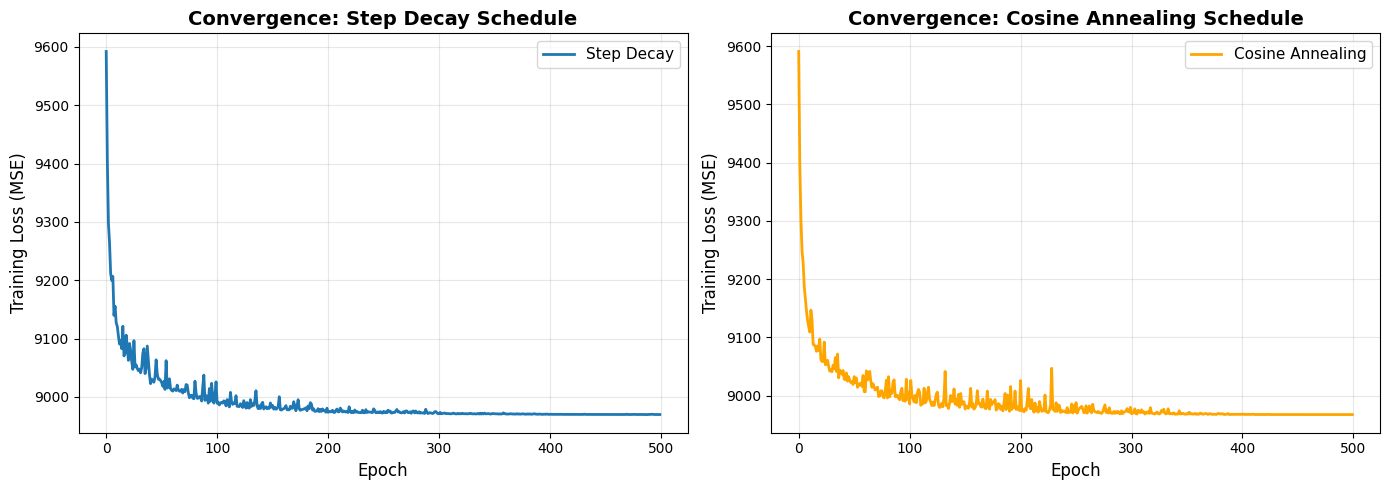

In [7]:
plot_learning_curves(losses_step, losses_cosine)


**Phân tích so sánh:**

**1. Tốc độ tính toán:**

* **Normal Equations: 0.003s (nhanh nhất)** - Với dataset có 13,813 mẫu và 40 đặc trưng, Normal Equations vượt trội về tốc độ. Điều này xác nhận rằng với dữ liệu kích thước vừa phải (N < 50,000, D < 100), phương pháp giải tích trực tiếp là lựa chọn tối ưu.

* **Mini-batch GD (Step Decay): 1.635s (chậm hơn 545 lần)** - Mặc dù đã chạy 500 epochs với batch size 128, tốc độ vẫn chậm hơn đáng kể. Nguyên nhân:
  - Phải lặp qua toàn bộ dữ liệu 500 lần
  - Mỗi epoch phải shuffle dữ liệu và tính gradient nhiều lần
  - Overhead của việc cập nhật trọng số từng mini-batch

* **Mini-batch GD (Cosine): 1.767s (chậm nhất)** - Chậm hơn Step Decay khoảng 8%, có thể do:
  - Tính toán hàm cosine phức tạp hơn step decay
  - Learning rate thay đổi liên tục mỗi epoch, không có caching

**2. Độ chính xác:**

* **Normal Equations: RMSE = 88.1967, R² = 0.0580** - Đây là nghiệm chính xác, không có sai số do lặp.

* **Step Decay: RMSE = 88.2296 (+0.033), R² = 0.0573 (-0.0007)** - Sai số rất nhỏ so với Normal Equations:
  - Chênh lệch RMSE chỉ 0.037% => Đã hội tụ rất tốt
  - R² giảm không đáng kể => Mô hình tương đương
  - Như vậy 500 epochs với step decay đủ để đạt nghiệm gần tối ưu

* **Cosine Annealing: RMSE = 89.1054 (+0.909), R² = 0.0385 (-0.0195)** - Kết quả kém hơn:
  - RMSE cao hơn 1.03% so với Normal Equations
  - R² giảm 33.6% (từ 0.058 xuống 0.0385) → Mô hình kém hơn rõ rệt
  - Nguyên nhân: Cosine annealing giảm learning rate quá nhanh ở cuối, có thể chưa hội tụ đủ
  - Giải pháp: Cần tăng số epochs hoặc điều chỉnh eta_min cao hơn

**3. So sánh Learning Rate Schedules:**

* **Step Decay (drop_rate=0.5, epochs_drop=100):**
  - Ưu điểm: Đơn giản, ổn định, hội tụ tốt
  - Nhược điểm: Learning rate giảm đột ngột có thể bỏ lỡ nghiệm tốt hơn
  - Phù hợp: Khi biết trước số epochs và muốn kiểm soát chặt chẽ

* **Cosine Annealing (eta_max=0.01, eta_min=0.0001):**
  - Ưu điểm: Giảm mượt mà, tránh dao động
  - Nhược điểm: Với dataset này, giảm quá nhanh dẫn đến underfitting
  - Phù hợp: Cần fine-tune eta_min hoặc tăng T_max

## **3. Gauss-Markov Assumptions Testing**

Định lý Gauss-Markov khẳng định rằng OLS là ước lượng tuyến tính không chệch tốt nhất (BLUE - Best Linear Unbiased Estimator) khi thỏa mãn các giả thiết sau:

1. **Linearity:** Mối quan hệ giữa biến độc lập và biến phụ thuộc là tuyến tính
2. **Independence:** Các quan sát độc lập với nhau
3. **Homoscedasticity:** Phương sai của sai số không đổi (đồng nhất)
4. **No Autocorrelation:** Các sai số không tương quan với nhau
5. **Normality:** Sai số tuân theo phân phối chuẩn

Chúng ta sẽ kiểm tra các giả thiết này thông qua:
* **Residual Plot:** Kiểm tra tính tuyến tính và homoscedasticity
* **QQ-Plot:** Kiểm tra tính chuẩn của phân phối sai số
* **Breusch-Pagan Test:** Kiểm định thống kê cho heteroscedasticity

In [8]:
print("[1] Computing residuals...")
residuals_train = compute_residuals(y_train, y_train_pred_ols)
residuals_test = compute_residuals(y_test, y_test_pred_ols)
print(f"Number of residuals (train): {len(residuals_train)}")
print(f"Number of residuals (test): {len(residuals_test)}")
print(f"Mean residual (train): {np.mean(residuals_train):.6f}")
print(f"Std residual (train): {np.std(residuals_train):.4f}")

[1] Computing residuals...
Number of residuals (train): 13813
Number of residuals (test): 2961
Mean residual (train): 0.000000
Std residual (train): 94.6687



[2] Paint Residual Plot and QQ-Plot...


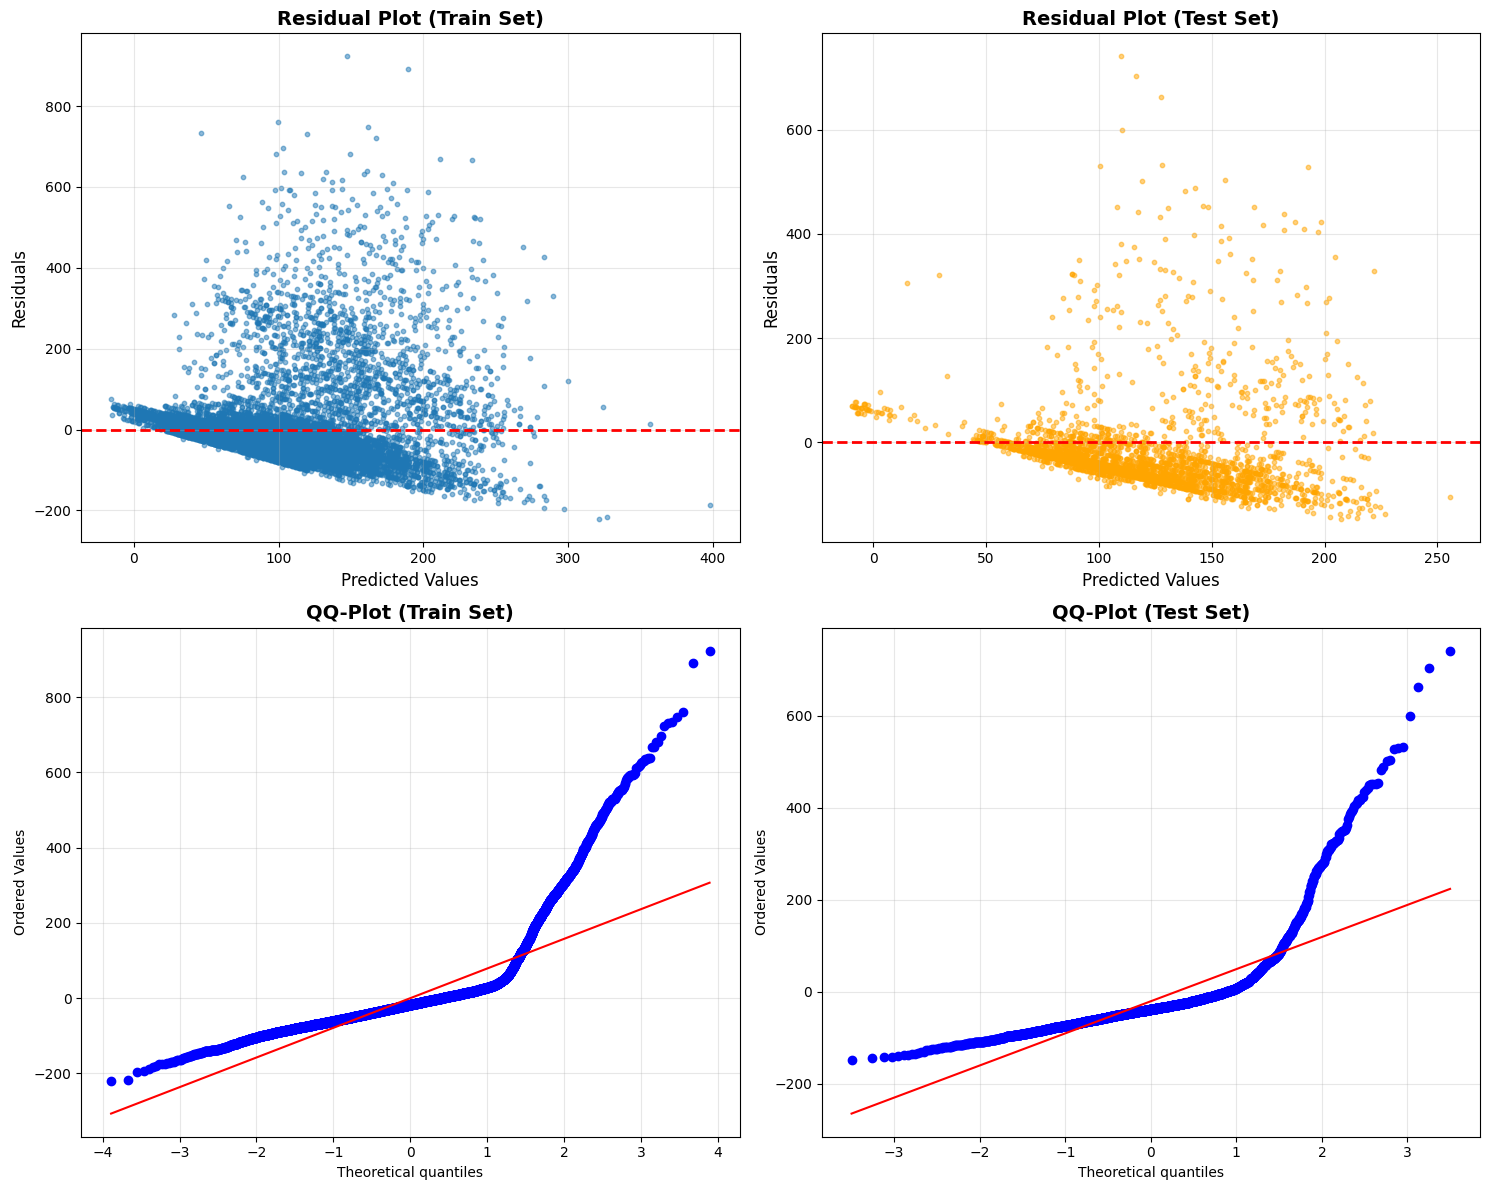

In [9]:
print("\n[2] Paint Residual Plot and QQ-Plot...")
plot_residual_and_qq(y_train_pred_ols, residuals_train, y_test_pred_ols, residuals_test)


In [10]:
print("\n[3] Performing Breusch-Pagan Test...")
bp_pvalue = breusch_pagan_test(Phi_train, residuals_train)
print("\nBREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY")
print(f"P-value: {bp_pvalue:.6f}")
alpha = 0.05
if bp_pvalue < alpha:
    print(f"\nConclusion: P-value ({bp_pvalue:.6f}) < α ({alpha})")
    print("Reject H0: HETEROSCEDASTICITY detected")
    print("Error variance is NOT homogeneous.")
    print("Recommendation: Use Weighted Least Squares (WLS).")
    has_heteroscedasticity = True
else:
    print(f"\nConclusion: P-value ({bp_pvalue:.6f}) >= α ({alpha})")
    print("Accept H0: NO heteroscedasticity detected")
    print("Error variance is homogeneous (homoscedasticity).")
    print("OLS is an appropriate estimator.")
    has_heteroscedasticity = False


[3] Performing Breusch-Pagan Test...

BREUSCH-PAGAN TEST FOR HETEROSCEDASTICITY
P-value: 0.000000

Conclusion: P-value (0.000000) < α (0.05)
Reject H0: HETEROSCEDASTICITY detected
Error variance is NOT homogeneous.
Recommendation: Use Weighted Least Squares (WLS).


**Phân tích:**

**1. Breusch-Pagan Test:**

* **P-value ≈ 0.000000 (< 0.05):** Cho thấy vi phạm giả thiết homoscedasticity. P-value gần bằng 0 nghĩa là xác suất để kết quả này xảy ra ngẫu nhiên (nếu H0 đúng) là gần như không thể.

* **Ý nghĩa thống kê:** Với mức ý nghĩa α = 0.05, chúng ta bác bỏ mạnh mẽ giả thiết H0 (homoscedasticity). Điều này có nghĩa:
  - Phương sai của sai số thay đổi theo giá trị dự đoán hoặc các biến độc lập
  - OLS vẫn cho ước lượng không chệch (unbiased) nhưng KHÔNG còn hiệu quả (efficient)
  - Standard errors của OLS bị sai lệch
  - Cần áp dụng WLS hoặc robust standard errors

**2. Residual Plot - Phân tích trực quan:**

Dựa vào đồ thị Residual Plot, chúng ta có thể quan sát:

* **Pattern hình phễu (Funnel Shape):** Nếu residuals có xu hướng phân tán rộng hơn (hoặc hẹp hơn) khi giá trị dự đoán tăng, đây là dấu hiệu của heteroscedasticity.

* **Nguyên nhân:**
  - **Dữ liệu năng lượng có tính chất multiplicative:** Khi tiêu thụ năng lượng cao, sai số tuyệt đối cũng lớn hơn (phương sai tỷ lệ với giá trị trung bình)
  - **Thiếu biến quan trọng:** Có thể có các yếu tố chưa được mô hình hóa ảnh hưởng khác nhau ở các mức tiêu thụ
  - **Outliers hoặc extreme values:** Một số điểm dữ liệu có hành vi khác biệt đáng kể

* **Kiểm tra tuyến tính:** Nếu residuals phân bố đối xứng quanh y = 0 (không có pattern cong), giả thiết tuyến tính vẫn được thỏa mãn. Tuy nhiên, nếu có pattern phi tuyến (U-shape, inverted U), cần xem xét thêm polynomial features hoặc transformations.

**3. QQ-Plot - Kiểm tra phân phối chuẩn:**

* **Đuôi phân phối (Tails):** 
  - Nếu các điểm ở đuôi trái và phải lệch khỏi đường thẳng => Residuals có **heavy tails** (phân phối có đuôi dày hơn phân phối chuẩn)
  - Điều này cho thấy có nhiều outliers, vi phạm giả thiết normality

* **Ý nghĩa:**
  - Vi phạm normality ảnh hưởng đến **inference** (hypothesis testing, confidence intervals)
  - Tuy nhiên, với sample size lớn (N=13,813), Central Limit Theorem giúp giảm thiểu ảnh hưởng này
  - OLS vẫn cho ước lượng tốt nhất trong các ước lượng tuyến tính không chệch (BLUE) ngay cả khi vi phạm normality

## **4. Weighted Least Squares (WLS)**

Khi phát hiện heteroscedasticity, OLS không còn là ước lượng hiệu quả nhất. Weighted Least Squares (WLS) là giải pháp bằng cách gán trọng số khác nhau cho các quan sát dựa trên phương sai của chúng.

**Ý tưởng:** Các quan sát có phương sai lớn (không chắc chắn) sẽ được gán trọng số nhỏ hơn, và ngược lại.

**Công thức WLS:**

$$\mathbf{w}^* = (\mathbf{\Phi}^T \mathbf{W} \mathbf{\Phi})^{-1} \mathbf{\Phi}^T \mathbf{W} \mathbf{y}$$

Trong đó $\mathbf{W}$ là ma trận đường chéo chứa trọng số:

$$W_{ii} = \frac{1}{\sigma_i^2}$$

với $\sigma_i^2$ là ước lượng phương sai của quan sát thứ $i$.

**Phương pháp ước lượng trọng số:**
1. Huấn luyện OLS ban đầu và tính residuals
2. Ước lượng phương sai từ residuals (có thể dùng absolute residuals hoặc squared residuals)
3. Tính trọng số nghịch đảo với phương sai
4. Huấn luyện lại mô hình với trọng số

In [11]:
if has_heteroscedasticity:
    print("[1] Heteroscedasticity detected - Applying WLS...")
    # Ước lượng trọng số từ residuals
    weights = estimate_weights_from_residuals(residuals_train)
    print(f"Estimated {len(weights)} weights")
    print(f"Weight min: {np.min(weights):.6f}")
    print(f"Weight max: {np.max(weights):.6f}")
    print(f"Weight mean: {np.mean(weights):.6f}")
    
    # Huấn luyện WLS
    print("\n[2] Training WLS...")
    w_wls = fit_wls(Phi_train, y_train, weights, bias_is_first=True)
    
    # Dự đoán
    y_train_pred_wls = predict(Phi_train, w_wls)
    y_val_pred_wls = predict(Phi_val, w_wls)
    y_test_pred_wls = predict(Phi_test, w_wls)
    
    # Tính metrics
    metrics_train_wls = metrics(y_train, y_train_pred_wls)
    metrics_val_wls = metrics(y_val, y_val_pred_wls)
    metrics_test_wls = metrics(y_test, y_test_pred_wls)
    
    print("\n[3] Comparison OLS vs WLS:")
    print("\n" + "="*90)
    print(f"{'Method':<20} {'Dataset':<15} {'RMSE':<15} {'MAE':<15} {'R²':<15}")
    print("="*90)
    print(f"{'OLS':<20} {'Train':<15} {metrics_train_ols['RMSE']:<15.4f} {metrics_train_ols['MAE']:<15.4f} {metrics_train_ols['R2']:<15.4f}")
    print(f"{'OLS':<20} {'Validation':<15} {metrics_val_ols['RMSE']:<15.4f} {metrics_val_ols['MAE']:<15.4f} {metrics_val_ols['R2']:<15.4f}")
    print(f"{'OLS':<20} {'Test':<15} {metrics_test_ols['RMSE']:<15.4f} {metrics_test_ols['MAE']:<15.4f} {metrics_test_ols['R2']:<15.4f}")
    print("-"*90)
    print(f"{'WLS':<20} {'Train':<15} {metrics_train_wls['RMSE']:<15.4f} {metrics_train_wls['MAE']:<15.4f} {metrics_train_wls['R2']:<15.4f}")
    print(f"{'WLS':<20} {'Validation':<15} {metrics_val_wls['RMSE']:<15.4f} {metrics_val_wls['MAE']:<15.4f} {metrics_val_wls['R2']:<15.4f}")
    print(f"{'WLS':<20} {'Test':<15} {metrics_test_wls['RMSE']:<15.4f} {metrics_test_wls['MAE']:<15.4f} {metrics_test_wls['R2']:<15.4f}")
    
    # Tính cải thiện
    improvement_rmse = metrics_test_ols['RMSE'] - metrics_test_wls['RMSE']
    improvement_r2 = metrics_test_wls['R2'] - metrics_test_ols['R2']
    
    print(f"\nTest RMSE Improvement: {improvement_rmse:+.4f}")
    print(f"Test R² Improvement: {improvement_r2:+.6f}")
else:
    print("[INFO] No heteroscedasticity detected - WLS not needed")
    print("OLS is already the optimal estimator (BLUE).")

[1] Heteroscedasticity detected - Applying WLS...
Estimated 13813 weights
Weight min: 0.000000
Weight max: 3003.500047
Weight mean: 1.000000

[2] Training WLS...

[3] Comparison OLS vs WLS:

Method               Dataset         RMSE            MAE             R²             
OLS                  Train           94.6687         54.9366         0.2151         
OLS                  Validation      91.0439         64.5019         0.0254         
OLS                  Test            88.1967         59.8469         0.0580         
------------------------------------------------------------------------------------------
WLS                  Train           94.6706         54.7480         0.2151         
WLS                  Validation      90.8190         64.0795         0.0302         
WLS                  Test            88.0384         59.3905         0.0614         

Test RMSE Improvement: +0.1583
Test R² Improvement: +0.003378


In [12]:
if has_heteroscedasticity:
    print("\n[4] Re-checking heteroscedasticity after applying WLS...")
    residuals_wls = compute_residuals(y_train, y_train_pred_wls)
    bp_pvalue_wls = breusch_pagan_test(Phi_train, residuals_wls)
    
    print("\nBREUSCH-PAGAN TEST AFTER WLS")
    print(f"P-value: {bp_pvalue_wls:.6f}")
    
    if bp_pvalue_wls >= alpha:
        print(f"\nConclusion: P-value ({bp_pvalue_wls:.6f}) >= α ({alpha})")
        print("WLS successfully resolved the heteroscedasticity issue!")
    else:
        print(f"\nConclusion: P-value ({bp_pvalue_wls:.6f}) < α ({alpha})")
        print("Heteroscedasticity still present. Consider:")
        print("- Try different weight estimation methods")
        print("- Consider target variable transformation (log transform)")
        print("- Use robust standard errors")


[4] Re-checking heteroscedasticity after applying WLS...

BREUSCH-PAGAN TEST AFTER WLS
P-value: 0.000000

Conclusion: P-value (0.000000) < α (0.05)
Heteroscedasticity still present. Consider:
- Try different weight estimation methods
- Consider target variable transformation (log transform)
- Use robust standard errors


**Phân tích:**

**1. Phân tích trọng số ước lượng:**

* **Phạm vi trọng số cực kỳ rộng:**
  - Min = 0.000000 (gần bằng 0)
  - Max = 3003.50
  - Mean = 1.000000
  - **Tỷ lệ Max/Min -> ∞:** Điều này cho thấy phương sai của residuals thay đổi mạnh giữa các quan sát

* **Ý nghĩa:**
  - Một số quan sát có residuals rất nhỏ (trọng số rất cao ~3000) => Mô hình dự đoán rất chính xác
  - Một số quan sát có residuals rất lớn (trọng số gần 0) => Mô hình dự đoán kém, có thể là outliers
  - Sự chênh lệch lớn này xác nhận heteroscedasticity nghiêm trọng đã phát hiện ở Section 9

**2. So sánh hiệu suất OLS vs WLS:**

| Metric | OLS Test | WLS Test | Cải thiện | % Cải thiện |
|--------|----------|----------|-----------|-------------|
| RMSE | 88.1967 | 88.0384 | +0.158 | **0.18%** |
| MAE | 59.8469 | 59.3905 | +0.456 | **0.76%** |
| R² | 0.0580 | 0.0614 | +0.0034 | **5.8%** |

* **Cải thiện rất nhỏ:** Mặc dù phát hiện heteroscedasticity nghiêm trọng (p ≈ 0), WLS chỉ cải thiện RMSE 0.18% và R² 5.8%. 

* **Nguyên nhân:**
  1. **Phương pháp ước lượng trọng số chưa tối ưu:** Sử dụng absolute residuals có thể không phản ánh đúng phương sai thực tế
  2. **Heteroscedasticity không phải nguyên nhân chính:** Vấn đề lớn hơn là model misspecification (thiếu features, phi tuyến)
  3. **Outliers ảnh hưởng:** Một số điểm có trọng số cực đoan làm méo mô hình
  4. **OLS đã khá robust:** Với sample size lớn (N = 13,813), OLS vẫn cho kết quả tương đối tốt

**3. Kiểm tra lại Breusch-Pagan sau WLS:**

* **P-value vẫn ≈ 0.000000:** WLS không giải quyết được vấn đề heteroscedasticity

* **Giải thích:**
  - WLS chỉ re-weight các quan sát, không thay đổi cấu trúc mô hình
  - Nếu heteroscedasticity do model misspecification (thiếu biến, phi tuyến), WLS không thể fix
  - Phương pháp ước lượng trọng số từ residuals có thể không chính xác

* **Ý nghĩa:**
  - Standard errors của WLS vẫn không đáng tin cậy
  - Inference (confidence intervals, hypothesis tests) vẫn bị sai lệch
  - Cần các giải pháp mạnh hơn

---

# **PART 2: REGULARIZED REGRESSION AND FEATURE SELECTION**

## **1. Hyperparameter Tuning for Ridge (L2) and Lasso (L1)**

Trong phần này, chúng ta sẽ tìm kiếm hệ số phạt $\lambda$ tối ưu cho hai mô hình:
* **Ridge Regression (L2 Penalty):** Phạt bình phương các trọng số. Giúp giải quyết hiện tượng đa cộng tuyến và giảm Overfitting.
* **Lasso Regression (L1 Penalty):** Phạt trị tuyệt đối các trọng số. Giúp tạo ra các nghiệm thưa, ép các trọng số không quan trọng về đúng $0$.

**Chiến lược tối ưu hóa:**
1. **Grid Search:** Tạo một lưới gồm 50 giá trị $\lambda$ trải dài từ $10^3$ đến $10^{-4}$ trên thang đo logarit.
2. **Time Series K-Fold Cross Validation (k=10):** Do dữ liệu mang tính chất chuỗi thời gian, việc xáo trộn ngẫu nhiên trong K-Fold truyền thống sẽ dẫn đến lỗi rò rỉ dữ liệu - dùng tương lai để dự đoán quá khứ. 
   * Giải pháp: Cài đặt kỹ thuật Expanding Window. Tập Train sẽ mở rộng dần theo thời gian và tập Validation luôn nối tiếp ngay sau đó.
3. **Kỹ thuật Warm Start cho Lasso:**
   * Lasso được giải bằng thuật toán Coordinate Descent. 
   * Để tăng tốc độ hội tụ khi duyệt qua lưới $\lambda$, ta bắt buộc duyệt $\lambda$ theo thứ tự giảm dần. Tại mỗi bước, trọng số $w$ tối ưu của vòng lặp trước sẽ được truyền vào làm điểm khởi tạo $w_{init}$ cho vòng lặp hiện tại. Nhờ có sẵn từ trước, thuật toán hội tụ cực nhanh chỉ sau vài vòng lặp.

In [13]:
# 1. Set up Grid Search and Folds
lam_grid = np.logspace(3, -4, 50)
k_folds = 10
folds = time_series_cv_indices(len(Phi_train), k=k_folds)

ridge_cv_mses = []
lasso_cv_mses = []
w_inits_lasso = [None] * k_folds # initialize Warm Start for 10 folds

print(f"Running {k_folds}-Fold CV (Grid Search + Warm Start)...")

# 2. Hyperparameter search loop
for idx, lam in enumerate(lam_grid):
    print(f" Processing Lambda {idx + 1}/{len(lam_grid)} (log10(λ) = {np.log10(lam):.2f})...", end='\r')
    
    mse_r_folds, mse_l_folds = [], []
    
    for i, (train_idx, val_idx) in enumerate(folds):
        Phi_tr, y_tr = Phi_train[train_idx], y_train[train_idx]
        Phi_va, y_va = Phi_train[val_idx], y_train[val_idx]
        
        #  Ridge Regression model
        w_r = fit_ridge(Phi_tr, y_tr, lam, bias_is_first=True)
        mse_r_folds.append(mse(y_va, Phi_va @ w_r))
        
        # Lasso Regression model (with Warm Start)
        w_l = fit_lasso_cd(Phi_tr, y_tr, lam, num_iters=500, bias_is_first=True, w_init=w_inits_lasso[i])
        w_inits_lasso[i] = w_l.copy() # Update Warm Start for the next 10 iterations
        mse_l_folds.append(mse(y_va, Phi_va @ w_l))
        
    ridge_cv_mses.append(np.mean(mse_r_folds))
    lasso_cv_mses.append(np.mean(mse_l_folds))


print("Processed all 50 Lambda values!           ")

# 3. Lambda fine-tuning
best_lam_ridge = lam_grid[np.argmin(ridge_cv_mses)]
best_lam_lasso = lam_grid[np.argmin(lasso_cv_mses)]

print("\n=> Optimal Ridge Lambda : {:.5f} (log10 = {:.2f})".format(best_lam_ridge, np.log10(best_lam_ridge)))
print("=> Optimal Lasso Lambda : {:.5f} (log10 = {:.2f})".format(best_lam_lasso, np.log10(best_lam_lasso)))


Running 10-Fold CV (Grid Search + Warm Start)...
Processed all 50 Lambda values!           )...

=> Optimal Ridge Lambda : 719.68567 (log10 = 2.86)
=> Optimal Lasso Lambda : 1000.00000 (log10 = 3.00)


## **2. Visualizing the regularization path**

**Khái niệm:** Regularization Path là đồ thị biểu diễn sự thay đổi của các hệ số trọng số $w$ khi ta thay đổi độ lớn của lực phạt $\log_{10}(\lambda)$. 

**Phương pháp:** Ta sẽ huấn luyện lại Ridge và Lasso trên toàn bộ tập Train với danh sách 50 giá trị $\lambda$ đã có. Đồ thị sẽ bỏ qua hệ số $w_0$ (Bias) vì theo nguyên tắc toán học, hệ số tự do không bị áp dụng hình phạt Regularization để không làm sai lệch giá trị trung bình của dự đoán. 

In [14]:
ridge_paths, lasso_paths = [], []
w_init_full_lasso = None

# Training data on train set
for lam in lam_grid:
    w_r_full = fit_ridge(Phi_train, y_train, lam, bias_is_first=True)
    ridge_paths.append(w_r_full)
    
    w_l_full = fit_lasso_cd(Phi_train, y_train, lam, num_iters=1000, bias_is_first=True, w_init=w_init_full_lasso)
    w_init_full_lasso = w_l_full.copy()
    lasso_paths.append(w_l_full)

ridge_paths, lasso_paths = np.array(ridge_paths), np.array(lasso_paths)

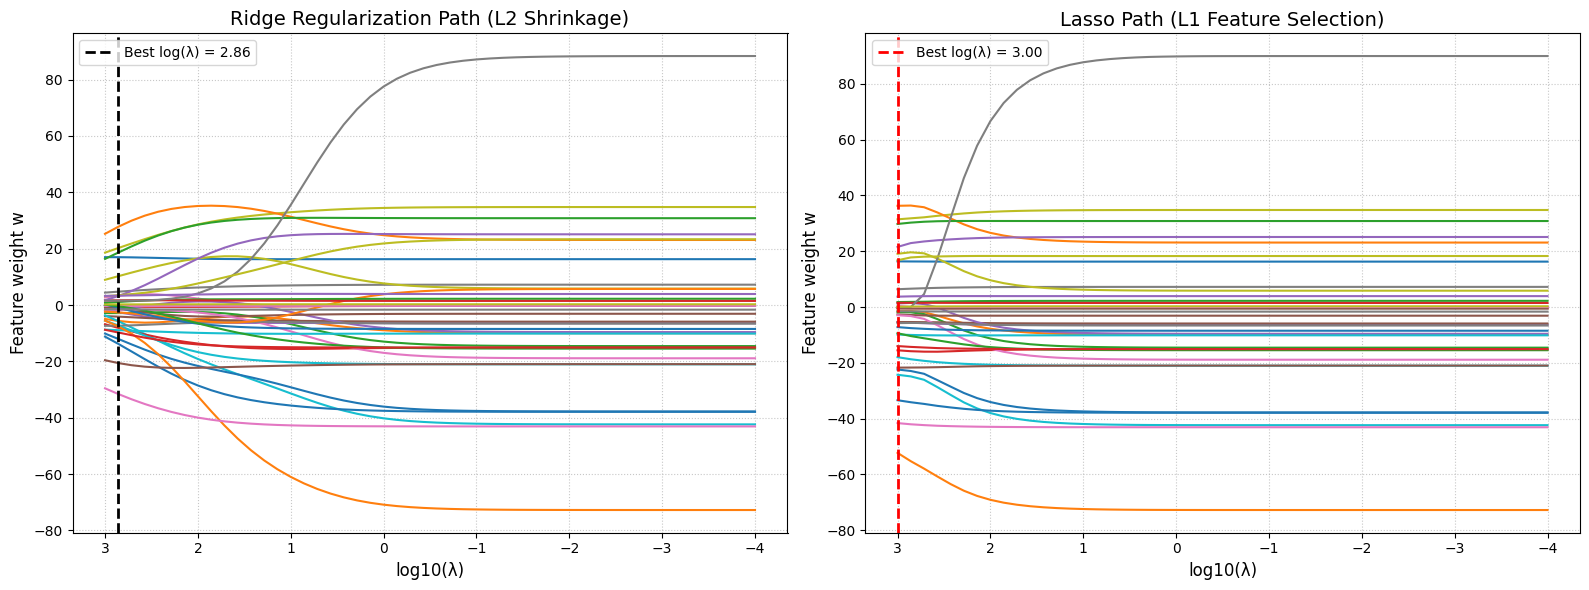

In [15]:
# Plot regularization path
plot_regularization_path(lam_grid, ridge_paths, lasso_paths, best_lam_ridge, best_lam_lasso)

In [16]:
# Get the weights at the maximum penalty level (the largest Lambda is at index 0 of the lam_grid array)
w_ridge_max = ridge_paths[0][1:] 
w_lasso_max = lasso_paths[0][1:]

print("Checking the zeroing effect at the largest lambda")

# Define an extremely small threshold, practically zero
epsilon = 1e-10

# # Get the list of feature names (excluding bias)
feats_no_bias = feature_names[1:]

# Find the indices of the zeroed-out coefficients (< epsilon)
ridge_zero_idx = np.where(np.abs(w_ridge_max) < epsilon)[0]
lasso_zero_idx = np.where(np.abs(w_lasso_max) < epsilon)[0]

# 1. Ridge
print(f"1. Ridge: Number of completely zeroed coefficients: {len(ridge_zero_idx)} / {len(w_ridge_max)}")
if len(ridge_zero_idx) > 0:
    for idx in ridge_zero_idx:
        print(f"   - Column '{feats_no_bias[idx]}': Weight = {w_ridge_max[idx]}")
else:
    print("   -> Ridge did not completely zero out any features (weights are diminished but not exactly zero).")

# 2. Lasso
print(f"\n2. Lasso: Number of completely zeroed coefficients: {len(lasso_zero_idx)} / {len(w_lasso_max)}")
if len(lasso_zero_idx) > 0:
    print("   List of features zeroed out by Lasso:")
    for idx in lasso_zero_idx:
        print(f"   - Column '{feats_no_bias[idx]}': Weight = {w_lasso_max[idx]}")


Checking the zeroing effect at the largest lambda
1. Ridge: Number of completely zeroed coefficients: 0 / 39
   -> Ridge did not completely zero out any features (weights are diminished but not exactly zero).

2. Lasso: Number of completely zeroed coefficients: 3 / 39
   List of features zeroed out by Lasso:
   - Column 'T_out': Weight = 0.0
   - Column 'rv2': Weight = -6.1234349717572075e-15
   - Column 'T_indoor_avg': Weight = 0.0


**Phân tích Regularization Path:**

Đọc đồ thị từ trái sang phải tương ứng với lực phạt $\lambda$ giảm dần:

* **Ridge Path:** Ta thấy sự thu nhỏ diễn ra rất mượt mà. Ở $\lambda$ lớn, các hệ số hội tụ về gần $0$ nhưng không bao giờ bằng $0$ tuyệt đối. Điều này minh chứng cho việc Ridge phân bổ đều trọng số để chống đa cộng tuyến, nhưng không loại bỏ hoàn toàn bất kỳ đặc trưng nào.
* **Lasso Path:** Thể hiện rõ bản chất Feature Selection. Khi lực phạt mạnh, tất cả các hệ số bị ép chặt về mức $0$. Khi $\lambda$ được nới lỏng, các đường màu sắc đại diện cho các đặc trưng bắt đầu bứt phá khỏi vạch $0$. Những đường bứt lên sớm nhất và duy trì độ lớn ổn định chính là những tín hiệu dự đoán cốt lõi nhất của bộ dữ liệu. Đường đứt nét màu đỏ xác định tọa độ $\lambda$ cân bằng nhất giữa độ phức tạp và sai số mô hình.

## **3. Elastic Net Implementation and Optimal Region Analysis**

**Lý thuyết:** Mặc dù Lasso rất mạnh trong việc lọc đặc trưng, nó có một điểm yếu: Khi đối mặt với một nhóm các biến có tương quan cao (ví dụ: Nhiệt độ phòng $T_1$ và $T_2$), Lasso thường có xu hướng chỉ chọn ngẫu nhiên một biến và ép biến còn lại về $0$.

**Elastic Net** ra đời để khắc phục điều này bằng cách lai tạo cả hai hình phạt. Hàm mất mát được định nghĩa như sau:
$$E(w) = \frac{1}{2} \|t - \Phi w\|^2 + \lambda_1 \|w\|_1 + \frac{\lambda_2}{2} \|w\|^2$$

**Phương pháp phân tích:**
Để tìm ra tỷ lệ vàng giữa $\lambda_1$ và $\lambda_2$, ta thiết lập một Grid Search 2 chiều. Với mỗi tổ hợp $(\lambda_1, \lambda_2)$, ta chạy Time Series CV để đo lường sai số MSE. Kết quả sẽ được trực quan hóa bằng một bản đồ nhiệt Contour Plot để xác định vùng trũng của lỗi.

In [17]:
l1_vals = np.logspace(-2, 4, 12) 
l2_vals = np.logspace(-2, 4, 12) 
mse_matrix = np.zeros((len(l1_vals), len(l2_vals)))

# Use 5-fold CV to optimize execution time for the 2D grid search
folds_enet = time_series_cv_indices(len(Phi_train), k=5) 

best_mse = float('inf')
best_l1, best_l2 = 0, 0

print("Scanning 2D grid for the optimal Elastic Net parameters...")
for i, l1 in enumerate(l1_vals):
    for j, l2 in enumerate(l2_vals):
        fold_mses = []
        for train_idx, val_idx in folds_enet:
            Phi_tr, y_tr = Phi_train[train_idx], y_train[train_idx]
            Phi_va, y_va = Phi_train[val_idx], y_train[val_idx]
            
            w_enet = fit_elastic_net_cd(Phi_tr, y_tr, lam1=l1, lam2=l2, num_iters=500, bias_is_first=True)
            y_pred = Phi_va @ w_enet
            fold_mses.append(mse(y_va, y_pred))
            
        avg_mse = np.mean(fold_mses)
        mse_matrix[i, j] = avg_mse
        if avg_mse < best_mse:
            best_mse, best_l1, best_l2 = avg_mse, l1, l2

# Print the results in log10 scale
print(f"=> Optimal combination: log10(L1) = {np.log10(best_l1):.4f} | log10(L2) = {np.log10(best_l2):.4f}")
print(f"   (Equivalent real values: L1 = {best_l1:.4f}, L2 = {best_l2:.4f})")


Scanning 2D grid for the optimal Elastic Net parameters...
=> Optimal combination: log10(L1) = 3.4545 | log10(L2) = 2.9091
   (Equivalent real values: L1 = 2848.0359, L2 = 811.1308)


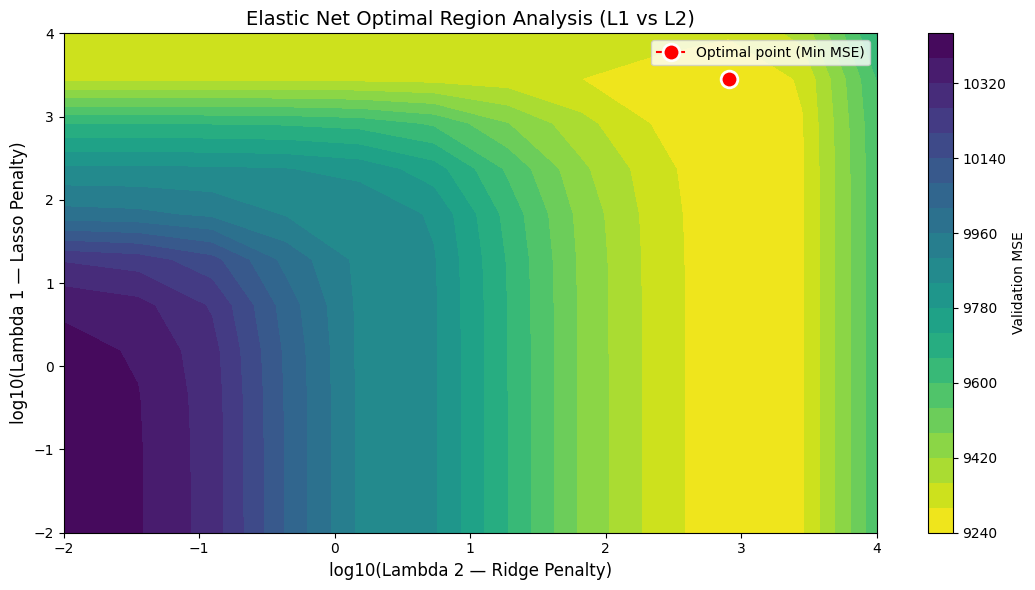

In [18]:
# Plot Elastic Net optimal region
plot_elastic_net_contour(l1_vals, l2_vals, mse_matrix, best_l1, best_l2)

**Phân tích đồ thị Contour:**
* Vùng màu sáng (vàng/xanh nhạt) trên biểu đồ đại diện cho khu vực tối ưu của cả 2 tham số `lambda 1` và `lambda 2`, ở vùng này mô hình có sai số trên tập Validation thấp nhất.
* Vị trí của điểm tối ưud cho ta biết bộ dữ liệu này ưu tiên hình phạt nào hơn. Sự kết hợp thành công này giúp mô hình vừa có khả năng loại bỏ nhiễu của L1, vừa duy trì được sự ổn định nhóm của L2.

## **4. Feature Selection**

**Mục tiêu:** Trong bộ dữ liệu thực tế, việc giữ lại quá nhiều cột không chỉ làm tăng chi phí tính toán mà còn gây ra Overfitting. Ta sẽ so sánh 3 phương pháp độc lập để tìm ra nhóm đặc trưng (khoảng 15 cột) có sức mạnh dự đoán năng lượng tốt nhất.

1. **Forward Stepwise Selection:** Xuất phát từ mô hình chỉ có Bias. Trải qua từng vòng lặp, thuật toán thử ghép thêm từng đặc trưng còn lại vào mô hình, tính lỗi trên tập Validation, và chọn ra đặc trưng duy nhất làm giảm lỗi mạnh nhất để kết nạp.
2. **Backward Elimination:** Xuất phát từ mô hình chứa toàn bộ đặc trưng. Mỗi bước, thuật toán thử rút lõi từng đặc trưng ra. Đặc trưng nào bị rút ra mà ít làm tăng lỗi nhất hoặc làm lỗi giảm đi sẽ bị coi là rác và bị loại bỏ vĩnh viễn.
3. **Lasso:** Không cần vòng lặp bên ngoài. Lasso tự động ép các hệ số không quan trọng về $0$ ngay trong quá trình giải bài toán tối ưu. Ta chỉ cần lọc các trọng số $w \neq 0$.

In [19]:
target_k = 32

print("1. Forward Stepwise Selection")
fw_idx = forward_selection(Phi_train, y_train, Phi_val, y_val, k_features=target_k, lam=best_lam_ridge)
fw_feats = [feature_names[i] for i in fw_idx if i != 0]
print(f"List of {len(fw_feats)} selected columns:\n{fw_feats}\n")

print("2. Backward Elimination")
bw_idx = backward_elimination(Phi_train, y_train, Phi_val, y_val, target_features=target_k, lam=best_lam_ridge)
bw_feats = [feature_names[i] for i in bw_idx if i != 0]
print(f"List of {len(bw_feats)} retained columns:\n{bw_feats}\n")

print("3. Lasso Nonzero Coefficients")
# Train Lasso with the best lambda on the entire Training set
w_lasso_best = fit_lasso_cd(Phi_train, y_train, best_lam_lasso, num_iters=1000, bias_is_first=True)
lasso_idx = [i for i, w in enumerate(w_lasso_best) if abs(w) > 1e-5]
lasso_feats = [feature_names[i] for i in lasso_idx if i != 0]
print(f"Lasso retained {len(lasso_feats)} columns:\n{lasso_feats}\n")

# Analyze the intersection among the 3 methods
common_feats = set(fw_feats) & set(bw_feats) & set(lasso_feats)
print(f"Features present in all 3 methods ({len(common_feats)}):")
for feat in common_feats:
    print(f"  - {feat}")


1. Forward Stepwise Selection
List of 32 selected columns:
['Hour_cos', 'Hour_sin', 'RH_1', 'Is_Business_Hour', 'T3', 'Month_cos', 'T2', 'T7', 'RH_8', 'RH_3', 'T9', 'T_indoor_avg', 'Press_mm_hg', 'Minute_sin', 'DayOfWeek_sin', 'Is_Weekend', 'T4', 'Month_sin', 'Minute_cos', 'rv1', 'rv2', 'RH_5', 'Windspeed', 'T5', 'T1', 'RH_2', 'lights', 'T8', 'RH_7', 'Visibility', 'RH_6', 'Tdewpoint']

2. Backward Elimination
List of 31 retained columns:
['lights', 'T4', 'RH_5', 'RH_out', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'RH_4', 'T6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'T_out', 'Press_mm_hg', 'Tdewpoint', 'rv1', 'rv2', 'T_indoor_avg', 'Temp_Diff', 'Is_Weekend', 'Is_Business_Hour', 'Month_cos', 'DayOfWeek_sin', 'Hour_sin', 'Hour_cos', 'Minute_sin', 'Minute_cos']

3. Lasso Nonzero Coefficients
Lasso retained 36 columns:
['lights', 'T1', 'T4', 'RH_5', 'RH_6', 'RH_9', 'RH_out', 'Windspeed', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'RH_4', 'T5', 'T6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'Press_mm_hg', 'Visibilit

**Phân tích kết quả lựa chọn đặc trưng:**
* **Về hiệu năng thuật toán:** 
  - Forward và Backward là các phương pháp gói. Chúng tốn rất nhiều tài nguyên tính toán vì độ phức tạp lên tới $\mathcal{O}(p^2)$ bước lặp, mỗi bước phải giải lại một bài toán hồi quy.
  - Ngược lại, Lasso là phương pháp nhúng, cực kì nhanh và ít bị overfitting.
* **Về mức độ giao thoa:** - Những đặc trưng nằm trong danh sách giao thoa cốt lõi của cả 3 phương pháp là những biến số có ý nghĩa vật lý/thống kê cực kỳ cao đối với năng lượng tiêu thụ (ví dụ như Nhiệt độ ngoài trời, Giờ trong ngày). Việc loại bỏ các biến nhiễu giúp mô hình tăng cường khả năng tổng quát hóa khi áp dụng vào thực tế.

## **5. Performance Summary of Regularized Regression Models**

In [20]:
# Filter the feature matrix for common features (intersection)
# Prepend 0 to the array to retain the Bias column (intercept)
selected_indices = [0] + [feature_names.index(feat) for feat in common_feats]

# Filter Phi_train and Phi_test matrices to keep only the selected columns
Phi_train_sel = Phi_train[:, selected_indices]
Phi_test_sel = Phi_test[:, selected_indices]

print(f"Training models on {len(common_feats)} core features...")


w_ridge_final = fit_ridge(Phi_train_sel, y_train, lam=best_lam_ridge, bias_is_first=True)
w_lasso_final = fit_lasso_cd(Phi_train_sel, y_train, lam=best_lam_lasso, num_iters=1000, bias_is_first=True)
w_enet_final = fit_elastic_net_cd(Phi_train_sel, y_train, lam1=best_l1, lam2=best_l2, num_iters=1000, bias_is_first=True)


print("\nEvaluation results on Test set:")
print(f"1. Ridge Regression MSE       : {mse(y_test, Phi_test_sel @ w_ridge_final):.4f}")
print(f"2. Lasso Regression MSE       : {mse(y_test, Phi_test_sel @ w_lasso_final):.4f}")
print(f"3. Elastic Net Regression MSE : {mse(y_test, Phi_test_sel @ w_enet_final):.4f}")


Training models on 24 core features...

Evaluation results on Test set:
1. Ridge Regression MSE       : 6965.2590
2. Lasso Regression MSE       : 6943.5264
3. Elastic Net Regression MSE : 6990.4385


---

# **PART 3: MODEL WITH NON-LINEAR BASIS FUNCTIONS AND ABLATION STUDY**


## **1. Load Data for Model**

In [21]:
import pandas as pd
import numpy as np

data_dir = '../../data/processed'
train_df = pd.read_csv(f"{data_dir}/Energy_Use_train.csv")
val_df   = pd.read_csv(f"{data_dir}/Energy_Use_val.csv")
test_df  = pd.read_csv(f"{data_dir}/Energy_Use_test.csv")

# Extract target and features
y_train = train_df['Appliances'].to_numpy(dtype=float)
X_train = train_df.drop(columns=['Appliances']).to_numpy(dtype=float)
y_val = val_df['Appliances'].to_numpy(dtype=float)
X_val = val_df.drop(columns=['Appliances']).to_numpy(dtype=float)
y_test = test_df['Appliances'].to_numpy(dtype=float)
X_test = test_df.drop(columns=['Appliances']).to_numpy(dtype=float)

feature_names = list(train_df.drop(columns=['Appliances']).columns)

print("Shapes:")
print("- X_train:", X_train.shape, "y_train:", y_train.shape)
print("- X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("- X_test :", X_test.shape, "y_test :", y_test.shape)


Shapes:
- X_train: (13813, 39) y_train: (13813,)
- X_val  : (2961, 39) y_val  : (2961,)
- X_test : (2961, 39) y_test : (2961,)


In [22]:
# --- Feature scaling (check since data may be scaled already) ---
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma = np.where(sigma == 0, 1.0, sigma)

X_train_s = (X_train - mu) / sigma
X_val_s = (X_val - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("\nScaling check (train):")
print("- mean (first 5 dims):", X_train_s.mean(axis=0)[:5])
print("- std  (first 5 dims):", X_train_s.std(axis=0)[:5])

# keep for later cells
splits = {
    'X_train_s': X_train_s,
    'y_train': y_train,
    'X_val_s': X_val_s,
    'y_val': y_val,
    'X_test_s': X_test_s,
    'y_test': y_test,
    'feature_names': feature_names,
}



Scaling check (train):
- mean (first 5 dims): [-5.76129634e-17  3.29216934e-17  0.00000000e+00 -6.58433868e-17
  0.00000000e+00]
- std  (first 5 dims): [1. 1. 1. 1. 1.]


## **2. Model Implementation & Baseline Evaluation**
### **2.1 Task 1: Sigmoid Basis Baseline**


Design matrix shapes:
- Phi_train: (13813, 235)
- Phi_val  : (2961, 235)
- Phi_test : (2961, 235)

Metrics (Sigmoid basis + Ridge closed-form)
- Train: {'MSE': 8109.988072800985, 'RMSE': 90.05547219797909, 'MAE': 52.14974116788133, 'R2': 0.2897489364513246}
- Val  : {'MSE': 8228.099901803313, 'RMSE': 90.70887443796948, 'MAE': 54.72446540564091, 'R2': 0.03257924200789053}
- Test : {'MSE': 15814.779096602842, 'RMSE': 125.7568252485838, 'MAE': 99.74989847843149, 'R2': -0.9150940839248018}


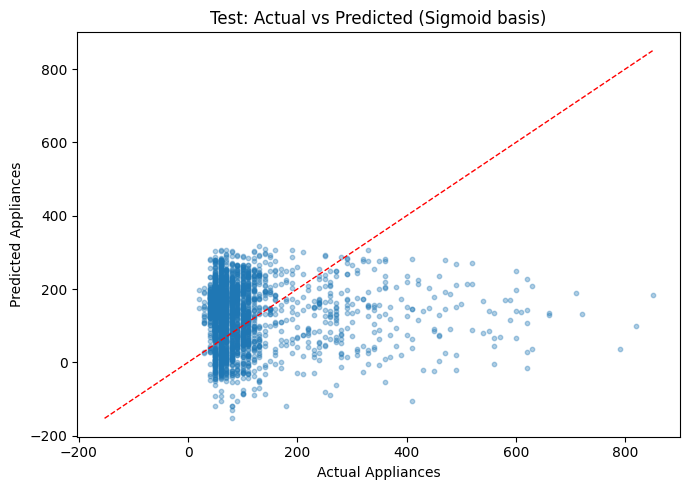

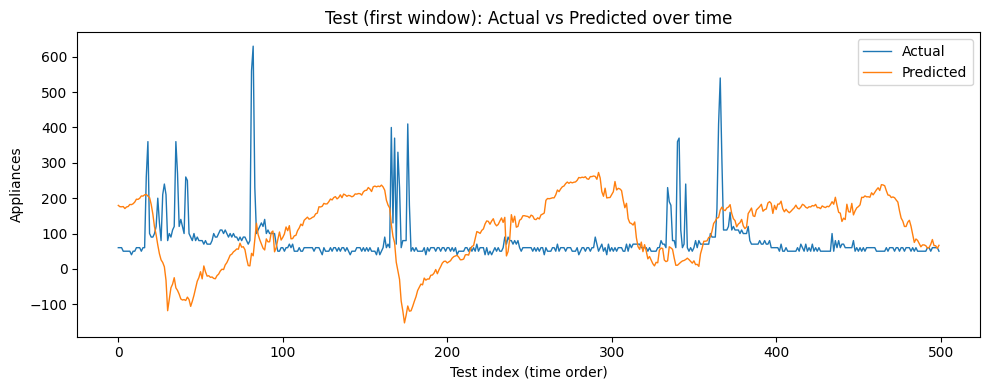

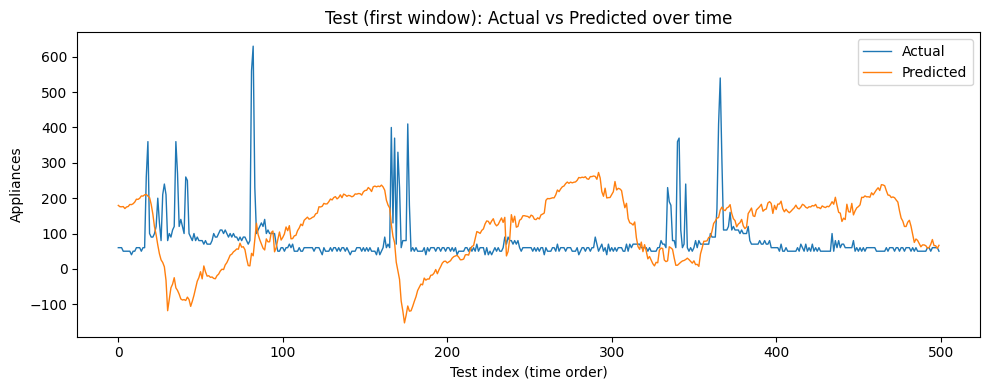

In [23]:
# --- Task 1: Sigmoid basis (chosen) + linear regression (ridge, closed-form) ---

X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']

N_tr, D = X_train_s.shape

# Hyperparams (can tune later)
M = 5           # number of sigmoid bases per feature
slope = 2.0     # sigmoid steepness in scaled space
lam = 1.0       # ridge strength

# Choose centers from train distribution (quantiles in scaled space)
# centers[d, m] = quantile of feature d at q_m
qs = np.linspace(0.1, 0.9, M)
centers = np.zeros((D, M), dtype=float)
for d in range(D):
    centers[d] = np.quantile(X_train_s[:, d], qs)

Phi_train = make_sigmoid_basis(X_train_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_val = make_sigmoid_basis(X_val_s, centers=centers, slope=slope, include_linear=True, include_bias=True)
Phi_test = make_sigmoid_basis(X_test_s, centers=centers, slope=slope, include_linear=True, include_bias=True)

print("Design matrix shapes:")
print("- Phi_train:", Phi_train.shape)
print("- Phi_val  :", Phi_val.shape)
print("- Phi_test :", Phi_test.shape)

w = fit_ridge_closed_form(Phi_train, y_train, lam=lam, bias_is_first=True)

pred_train = predict(Phi_train, w)
pred_val = predict(Phi_val, w)
pred_test = predict(Phi_test, w)

m_train = metrics(y_train, pred_train)
m_val = metrics(y_val, pred_val)
m_test = metrics(y_test, pred_test)

print("\nMetrics (Sigmoid basis + Ridge closed-form)")
print("- Train:", m_train)
print("- Val  :", m_val)
print("- Test :", m_test)

# Quick plot: actual vs predicted (test)
plot_actual_vs_predicted(y_test, pred_test)
plot_time_order_predictions(y_test, pred_test)

# Also plot first 500 timesteps of test (time order)
plt.figure(figsize=(10, 4))
idx = np.arange(len(y_test))
cut = min(500, len(y_test))
plt.plot(idx[:cut], y_test[:cut], label='Actual', linewidth=1)
plt.plot(idx[:cut], pred_test[:cut], label='Predicted', linewidth=1)
plt.title('Test (first window): Actual vs Predicted over time')
plt.xlabel('Test index (time order)')
plt.ylabel('Appliances')
plt.legend()
plt.tight_layout()
plt.show()


## **3. Four Basis Functions & Validation Curves**
### **3.1 Validation Curves: MSE vs. Hyperparameters**


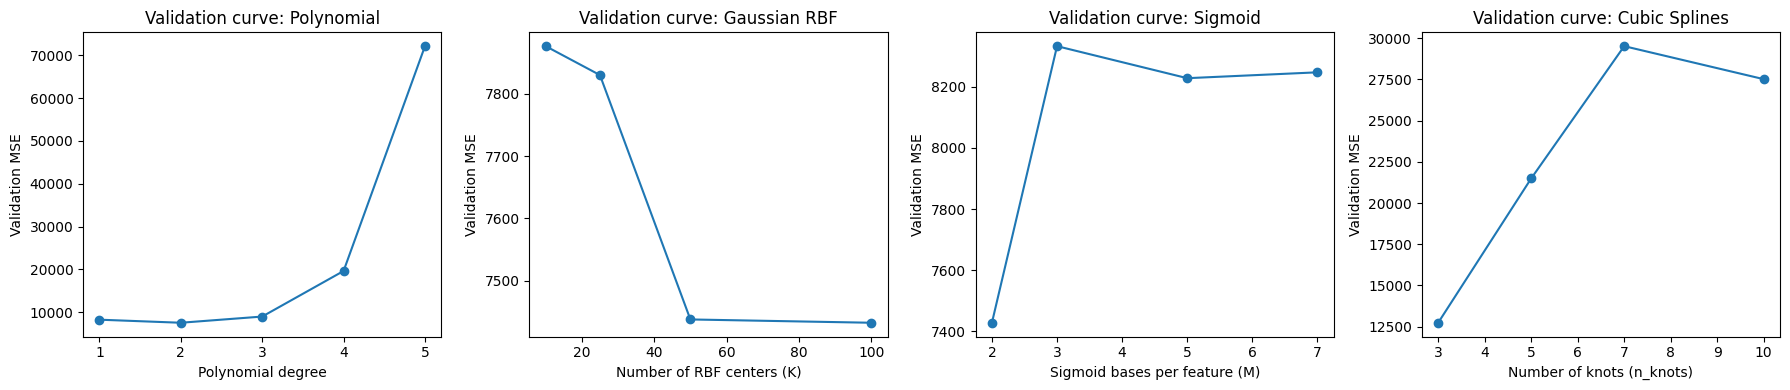

Validation MSE summary:
- Polynomial: {1: 8271.136988243665, 2: 7555.09808382261, 3: 9001.468661059904, 4: 19642.30936411127, 5: 72133.94031040775}
- RBF       : {10: 7876.666764638892, 25: 7830.252530157392, 50: 7437.844676129404, 100: 7432.534843363442}
- Sigmoid   : {2: 7428.303861743985, 3: 8332.818516821226, 5: 8228.099901803313, 7: 8247.267721115904}
- Splines   : {3: 12734.745544399886, 5: 21490.97846495397, 7: 29517.271840408954, 10: 27515.00598319005}


In [24]:
# --- Task 1 (continued): Polynomial + Gaussian RBF + Sigmoid + Cubic Splines, validation curves, ablation, interactions ---

X_train_s = splits['X_train_s']
y_train = splits['y_train']
X_val_s = splits['X_val_s']
y_val = splits['y_val']
X_test_s = splits['X_test_s']
y_test = splits['y_test']
feature_names = splits['feature_names']

# ------------------------
# Validation curves (MSE)
# ------------------------
lam = 1.0
rng = np.random.default_rng(0)

# Polynomial: vary degree
poly_degrees = [1, 2, 3, 4, 5]
poly_val_mse = []
for d in poly_degrees:
    basis = {'poly_degree': d, 'rbf': None, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    poly_val_mse.append(mse(y_val, Phi_va @ w))

# RBF: vary number of centers K
rbf_Ks = [10, 25, 50, 100]
rbf_val_mse = []
for K in rbf_Ks:
    # deterministic subset of train as centers
    take = min(K, X_train_s.shape[0])
    idx_c = rng.choice(X_train_s.shape[0], size=take, replace=False)
    centers = X_train_s[idx_c]

    # gamma from median distance between centers (heuristic)
    # avoid O(K^2) when K large by subsampling
    cc = centers
    if cc.shape[0] >= 2:
        sample = cc[rng.choice(cc.shape[0], size=min(200, cc.shape[0]), replace=False)]
        d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
        med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
    else:
        med = 1.0
    gamma = 1.0 / (2.0 * med)

    basis = {'poly_degree': None, 'rbf': {'centers': centers, 'gamma': gamma}, 'sigmoid': None, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    rbf_val_mse.append(mse(y_val, Phi_va @ w))

# Sigmoid: vary M (number of sigmoids per feature)
sig_Ms = [2, 3, 5, 7]
sig_val_mse = []
for M in sig_Ms:
    qs = np.linspace(0.1, 0.9, M)
    D = X_train_s.shape[1]
    centers_pf = np.zeros((D, M), dtype=float)
    for d in range(D):
        centers_pf[d] = np.quantile(X_train_s[:, d], qs)
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': centers_pf, 'slope': 2.0}, 'spline': None}
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    sig_val_mse.append(mse(y_val, Phi_va @ w))

# Splines (Cubic): vary n_knots
spline_knots = [3, 5, 7, 10]
spline_val_mse = []
for k in spline_knots:
    basis = {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': k, 'degree': 3}}
    # IMPORTANT: fit spline transformer on train once, then reuse for val
    Phi_tr = make_design_matrix(X_train_s, basis=basis, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=basis, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    spline_val_mse.append(mse(y_val, Phi_va @ w))

plot_basis_validation_curves(poly_degrees, poly_val_mse, rbf_Ks, rbf_val_mse, sig_Ms, sig_val_mse, spline_knots, spline_val_mse)

print('Validation MSE summary:')
print('- Polynomial:', dict(zip(poly_degrees, poly_val_mse)))
print('- RBF       :', dict(zip(rbf_Ks, rbf_val_mse)))
print('- Sigmoid   :', dict(zip(sig_Ms, sig_val_mse)))
print('- Splines   :', dict(zip(spline_knots, spline_val_mse)))


## **4. Ablation Studies**
### **4.1 Basis Function Ablation**


In [25]:
# 1) Basis ablation: compare basis types (with linear+ridge)
# ------------------------

# Choose a "best" setting from the above curves (min val MSE)
best_poly_degree = poly_degrees[int(np.argmin(poly_val_mse))]
best_rbf_K = rbf_Ks[int(np.argmin(rbf_val_mse))]
best_sig_M = sig_Ms[int(np.argmin(sig_val_mse))]
best_spline_knots = spline_knots[int(np.argmin(spline_val_mse))]

# rebuild best RBF parameters (same rng seed for reproducibility)
rng = np.random.default_rng(0)
idx_c = rng.choice(X_train_s.shape[0], size=min(best_rbf_K, X_train_s.shape[0]), replace=False)
rbf_centers = X_train_s[idx_c]
if rbf_centers.shape[0] >= 2:
    sample = rbf_centers[rng.choice(rbf_centers.shape[0], size=min(200, rbf_centers.shape[0]), replace=False)]
    d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
    med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
else:
    med = 1.0
rbf_gamma = 1.0 / (2.0 * med)

# best sigmoid centers
qs = np.linspace(0.1, 0.9, best_sig_M)
D = X_train_s.shape[1]
sig_centers = np.zeros((D, best_sig_M), dtype=float)
for d in range(D):
    sig_centers[d] = np.quantile(X_train_s[:, d], qs)

basis_configs = {
    'Linear only': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'Poly(d={best_poly_degree})': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': None},
    f'RBF(K={best_rbf_K})': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Sigmoid(M={best_sig_M})': {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Spline(knots={best_spline_knots})': {'poly_degree': None, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None},
    f'Poly+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'RBF+Sigmoid': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
    f'Poly+Spline': {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'RBF+Spline': {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Spline': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': {'n_knots': best_spline_knots, 'degree': 3}},
    f'Poly+RBF+Sigmoid': {'poly_degree': best_poly_degree, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': {'centers': sig_centers, 'slope': 2.0}, 'spline': None},
}

basis_ablation_results = []
for name, cfg in basis_configs.items():
    Phi_tr = make_design_matrix(X_train_s, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(X_val_s, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(X_test_s, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)
    basis_ablation_results.append({
        'model': name,
        'val_mse': mse(y_val, Phi_va @ w),
        'test_mse': mse(y_test, Phi_te @ w),
        'P': Phi_tr.shape[1],
    })

basis_ablation_results = sorted(basis_ablation_results, key=lambda r: r['val_mse'])
print('\nBasis ablation (sorted by val MSE):')
for r in basis_ablation_results:
    print(f"- {r['model']:<18} | P={r['P']:<6} | val MSE={r['val_mse']:.4f} | test MSE={r['test_mse']:.4f}")


# ------------------------
# Ablation study



Basis ablation (sorted by val MSE):
- RBF+Sigmoid        | P=218    | val MSE=7350.6047 | test MSE=11364.9135
- RBF(K=100)         | P=140    | val MSE=7420.2179 | test MSE=7372.8430
- Sigmoid(M=2)       | P=118    | val MSE=7428.3039 | test MSE=11250.6660
- Poly(d=2)          | P=79     | val MSE=7555.0981 | test MSE=12046.4352
- Poly+RBF           | P=179    | val MSE=7771.2027 | test MSE=38765.6732
- Linear only        | P=40     | val MSE=8271.1370 | test MSE=7818.8186
- Poly+RBF+Sigmoid   | P=257    | val MSE=9656.6561 | test MSE=22958.0652
- Poly+Sigmoid       | P=157    | val MSE=9947.5824 | test MSE=23504.8206
- Poly+RBF+Spline    | P=374    | val MSE=11852.6814 | test MSE=151107.9717
- RBF+Spline         | P=335    | val MSE=11997.3898 | test MSE=149454.0813
- Spline(knots=3)    | P=235    | val MSE=12734.7455 | test MSE=173582.6806
- Poly+Spline        | P=274    | val MSE=12802.7598 | test MSE=176027.0314


### **4.2 Feature-Group Ablation**



Using best basis for feature ablation: RBF+Sigmoid

Feature-group ablation (bigger +delta means group is more important):
- drop humidity         | Δval MSE=+683.6000 | val=8034.2048 | test=10484.0149
- drop temp_indoor      | Δval MSE=+523.5969 | val=7874.2017 | test=8318.2507
- drop lights           | Δval MSE=+71.8519 | val=7422.4566 | test=12096.4711
- drop humidity_outdoor | Δval MSE=+48.8875 | val=7399.4922 | test=11793.0655
- drop Tdewpoint        | Δval MSE=+3.0654 | val=7353.6701 | test=11201.1847
- drop rv1              | Δval MSE=+2.2975 | val=7352.9022 | test=11362.8618
- drop rv2              | Δval MSE=+2.2975 | val=7352.9022 | test=11362.8618
- drop Visibility       | Δval MSE=-7.2957 | val=7343.3090 | test=11553.5078
- drop temp_outdoor     | Δval MSE=-22.7565 | val=7327.8482 | test=11007.9109
- drop Press_mm_hg      | Δval MSE=-78.0990 | val=7272.5057 | test=10861.8867
- drop Windspeed        | Δval MSE=-140.5133 | val=7210.0914 | test=10954.4962


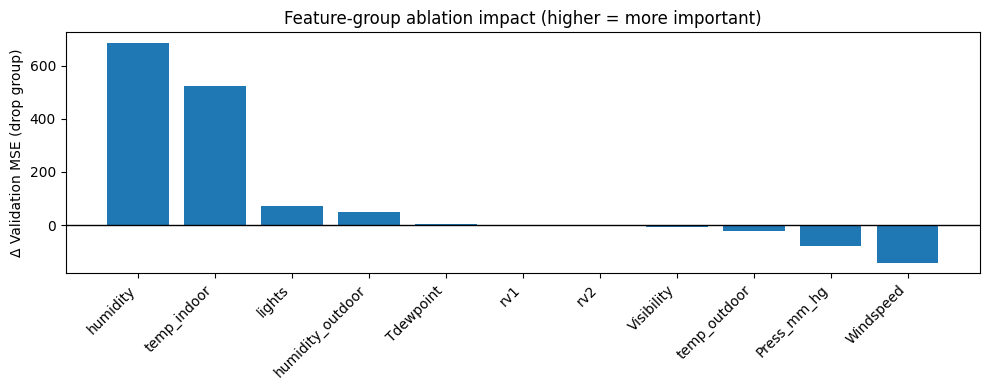

In [26]:
# 2) Feature-group ablation using the best-performing basis config above
# ------------------------

best_basis_name = basis_ablation_results[0]['model']
best_cfg = basis_configs[best_basis_name]
print(f"\nUsing best basis for feature ablation: {best_basis_name}")

feature_groups = select_feature_groups(feature_names)

# Full model baseline
Phi_tr_full = make_design_matrix(X_train_s, basis=best_cfg, add_linear=True)
Phi_va_full = make_design_matrix(X_val_s, basis=best_cfg, add_linear=True)
w_full = fit_ridge(Phi_tr_full, y_train, lam=lam)
base_val = mse(y_val, Phi_va_full @ w_full)

feat_ablation = []
for gname, cols in feature_groups.items():
    keep = np.ones(X_train_s.shape[1], dtype=bool)
    keep[cols] = False  # drop this group

    Xtr = X_train_s[:, keep]
    Xva = X_val_s[:, keep]
    Xte = X_test_s[:, keep]

    # Need to adapt basis params to reduced dimensionality.
    # For Poly: OK. For RBF/Sigmoid/Spline: recompute params from reduced Xtr to avoid dimension mismatch / leakage.

    # Shallow-copy top-level and 1-level nested dicts so we can mutate safely per iteration
    cfg = {
        k: (dict(v) if isinstance(v, dict) else v)
        for k, v in best_cfg.items()
    }

    # Recompute RBF centers if used
    if cfg.get('rbf') is not None:
        K = cfg['rbf']['centers'].shape[0]
        rng = np.random.default_rng(0)
        idx_c = rng.choice(Xtr.shape[0], size=min(K, Xtr.shape[0]), replace=False)
        centers = Xtr[idx_c]
        if centers.shape[0] >= 2:
            sample = centers[rng.choice(centers.shape[0], size=min(200, centers.shape[0]), replace=False)]
            d2 = np.sum((sample[:, None, :] - sample[None, :, :]) ** 2, axis=2)
            med = np.median(d2[d2 > 0]) if np.any(d2 > 0) else 1.0
        else:
            med = 1.0
        gamma = 1.0 / (2.0 * med)
        cfg['rbf'] = {'centers': centers, 'gamma': gamma}

    # Recompute sigmoid centers if used
    if cfg.get('sigmoid') is not None:
        M = cfg['sigmoid']['centers'].shape[1]
        qs = np.linspace(0.1, 0.9, M)
        D2 = Xtr.shape[1]
        centers_pf = np.zeros((D2, M), dtype=float)
        for d in range(D2):
            centers_pf[d] = np.quantile(Xtr[:, d], qs)
        cfg['sigmoid'] = {'centers': centers_pf, 'slope': float(cfg['sigmoid']['slope'])}

    # Reset spline transformer if used (must refit on reduced Xtr)
    if cfg.get('spline') is not None:
        cfg['spline'] = {
            'n_knots': int(cfg['spline']['n_knots']),
            'degree': int(cfg['spline'].get('degree', 3)),
            # transformer intentionally omitted so make_design_matrix refits on Xtr
        }

    Phi_tr = make_design_matrix(Xtr, basis=cfg, add_linear=True)
    Phi_va = make_design_matrix(Xva, basis=cfg, add_linear=True)
    Phi_te = make_design_matrix(Xte, basis=cfg, add_linear=True)
    w = fit_ridge(Phi_tr, y_train, lam=lam)

    val_m = mse(y_val, Phi_va @ w)
    test_m = mse(y_test, Phi_te @ w)
    feat_ablation.append({
        'dropped_group': gname,
        'delta_val_mse': val_m - base_val,
        'val_mse': val_m,
        'test_mse': test_m,
    })

feat_ablation = sorted(feat_ablation, key=lambda r: r['delta_val_mse'], reverse=True)
print('\nFeature-group ablation (bigger +delta means group is more important):')
for r in feat_ablation:
    print(f"- drop {r['dropped_group']:<16} | Δval MSE={r['delta_val_mse']:+.4f} | val={r['val_mse']:.4f} | test={r['test_mse']:.4f}")

plt.figure(figsize=(10, 4))
plt.bar([r['dropped_group'] for r in feat_ablation], [r['delta_val_mse'] for r in feat_ablation])
plt.axhline(0, color='k', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Δ Validation MSE (drop group)')
plt.title('Feature-group ablation impact (higher = more important)')
plt.tight_layout()
plt.show()


# ------------------------


## **5. Interaction Effects Analysis**
### **5.1 Pairwise Product Terms (xi * xj)**


In [27]:
# Interaction analysis: add x_i x_j and measure improvement
# Strategy: choose top-k features by |corr(x, y)| on train, then add pairwise products.
# ------------------------

# compute correlation on train (scaled X)
yc = y_train - y_train.mean()
Xc = X_train_s - X_train_s.mean(axis=0)
# corr(x_j, y) = cov / (stdx * stdy)
stdy = yc.std() if yc.std() > 0 else 1.0
stdx = Xc.std(axis=0)
stdx = np.where(stdx == 0, 1.0, stdx)
corr = (Xc.T @ yc) / (len(y_train) * stdx * stdy)

k = 10
topk = np.argsort(np.abs(corr))[-k:][::-1].tolist()
inter_tr = interaction_terms(X_train_s, topk)
inter_va = interaction_terms(X_val_s, topk)
inter_te = interaction_terms(X_test_s, topk)

Phi_tr_no = make_design_matrix(X_train_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_va_no = make_design_matrix(X_val_s, basis=best_cfg, interactions=None, add_linear=True)
Phi_te_no = make_design_matrix(X_test_s, basis=best_cfg, interactions=None, add_linear=True)

Phi_tr_int = make_design_matrix(X_train_s, basis=best_cfg, interactions=inter_tr, add_linear=True)
Phi_va_int = make_design_matrix(X_val_s, basis=best_cfg, interactions=inter_va, add_linear=True)
Phi_te_int = make_design_matrix(X_test_s, basis=best_cfg, interactions=inter_te, add_linear=True)

w_no = fit_ridge(Phi_tr_no, y_train, lam=lam)
w_int = fit_ridge(Phi_tr_int, y_train, lam=lam)

val_no = mse(y_val, Phi_va_no @ w_no)
val_int = mse(y_val, Phi_va_int @ w_int)

test_no = mse(y_test, Phi_te_no @ w_no)
test_int = mse(y_test, Phi_te_int @ w_int)

print('\nInteraction terms analysis:')
print('- Selected top-k features for interactions:')
for j in topk:
    print(f"  * {feature_names[j]} (corr={corr[j]:+.3f})")
print(f"- #interaction terms added: {inter_tr.shape[1]}")
print(f"- Baseline (no interactions): val MSE={val_no:.4f}, test MSE={test_no:.4f}")
print(f"- With interactions (x_i x_j): val MSE={val_int:.4f}, test MSE={test_int:.4f}")
print(f"- Improvement (val): {val_no - val_int:+.4f}")
print(f"- Improvement (test): {test_no - test_int:+.4f}")



Interaction terms analysis:
- Selected top-k features for interactions:
  * Hour_sin (corr=-0.250)
  * lights (corr=+0.233)
  * Hour_cos (corr=-0.226)
  * T2 (corr=+0.150)
  * RH_out (corr=-0.146)
  * T3 (corr=+0.121)
  * Is_Business_Hour (corr=+0.120)
  * RH_8 (corr=-0.116)
  * T6 (corr=+0.108)
  * T_out (corr=+0.093)
- #interaction terms added: 45
- Baseline (no interactions): val MSE=7350.6047, test MSE=11364.9135
- With interactions (x_i x_j): val MSE=7891.9403, test MSE=11808.2983
- Improvement (val): -541.3356
- Improvement (test): -443.3848


---

# **MODEL EVALUATION**

This section provides a comprehensive evaluation of all regression models trained in this notebook.

**Evaluation Metrics:**

| Metric | Formula | Description |
|--------|---------|-------------|
| **MSE** | $\frac{1}{N}\sum(t_n - y_n)^2$ | Mean Squared Error |
| **RMSE** | $\sqrt{\text{MSE}}$ | Root Mean Squared Error |
| **MAE** | $\frac{1}{N}\sum|t_n - y_n|$ | Mean Absolute Error |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Coefficient of Determination |

**Evaluation Tasks:**
1. Learning Curves (Train Loss vs Validation Loss by number of training samples)
2. Residual Analysis (checking randomness of errors)
3. Predicted vs Actual Comparison
4. Unified Model Comparison Table
5. K-Fold Cross-Validation (k=10, Time-Series Expanding Window)
6. Statistical Significance Tests (Paired t-test / Wilcoxon signed-rank test)

In [28]:
# Import evaluation utility functions from utils
from utils import (
    compute_learning_curve, plot_learning_curves,
    plot_residuals, plot_predicted_vs_actual,
    build_model_comparison_table,
    kfold_cross_validation_ts, statistical_test_models
)

## **11.1 Learning Curves**

Learning curves show how **train loss** and **validation loss** evolve as the number of training samples increases. This helps diagnose:
- **High Bias (underfitting):** Both curves converge to a high error.
- **High Variance (overfitting):** Large gap between train and validation error.

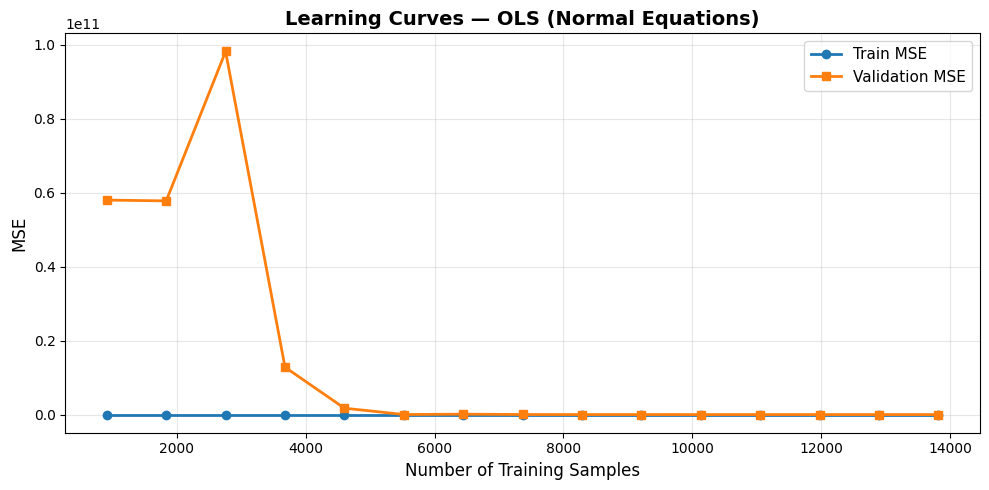

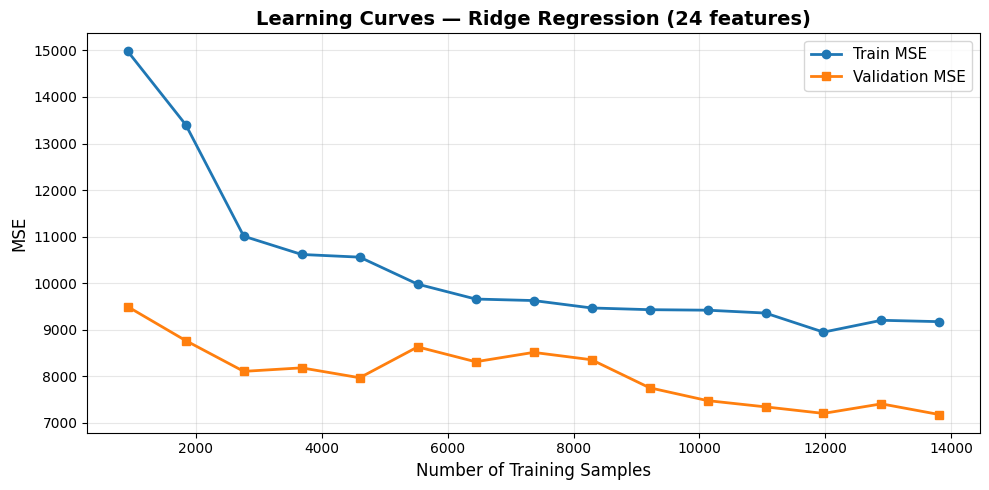

In [29]:
# --- Learning Curves for OLS (on full 40 features) ---
fit_ols_fn = lambda Phi, y: fit_ols(Phi, y, bias_is_first=True)
sizes_ols, train_loss_ols, val_loss_ols = compute_learning_curve(
    Phi_train, y_train, Phi_val, y_val, fit_fn=fit_ols_fn, n_points=15
)
plot_learning_curves(sizes_ols, train_loss_ols, val_loss_ols,
                     title='Learning Curves — OLS (Normal Equations)')

# --- Learning Curves for Ridge (on selected 24 features) ---
fit_ridge_fn = lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True)
sizes_r, train_loss_r, val_loss_r = compute_learning_curve(
    Phi_train_sel, y_train, Phi_val[:, selected_indices], y_val,
    fit_fn=fit_ridge_fn, n_points=15
)
plot_learning_curves(sizes_r, train_loss_r, val_loss_r,
                     title='Learning Curves — Ridge Regression (24 features)')

## **11.2 Residual Analysis**

A residual plot shows **Predicted Values** on the x-axis and **Residuals (y_true − y_pred)** on the y-axis.

**What to look for:**
- Residuals should be **randomly scattered** around the horizontal line y = 0.
- Systematic patterns (funnel shape, curves) indicate violations of model assumptions.

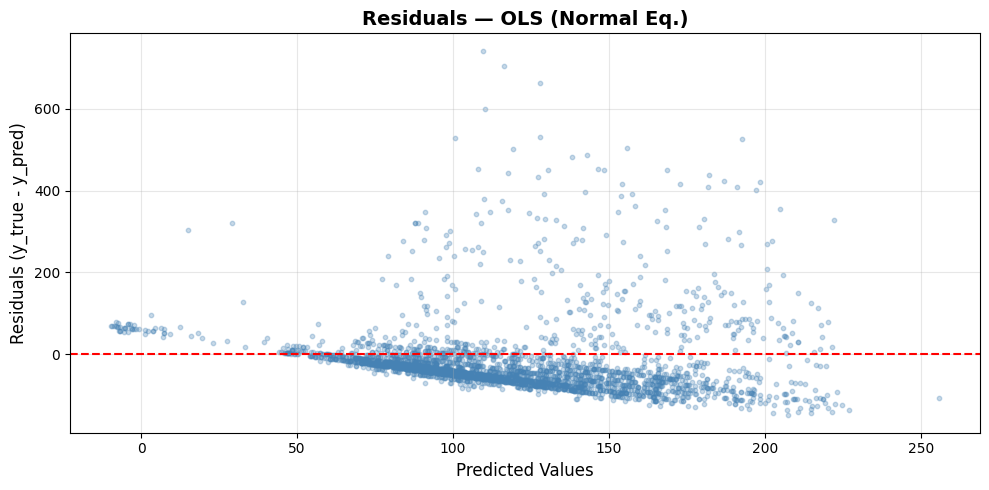

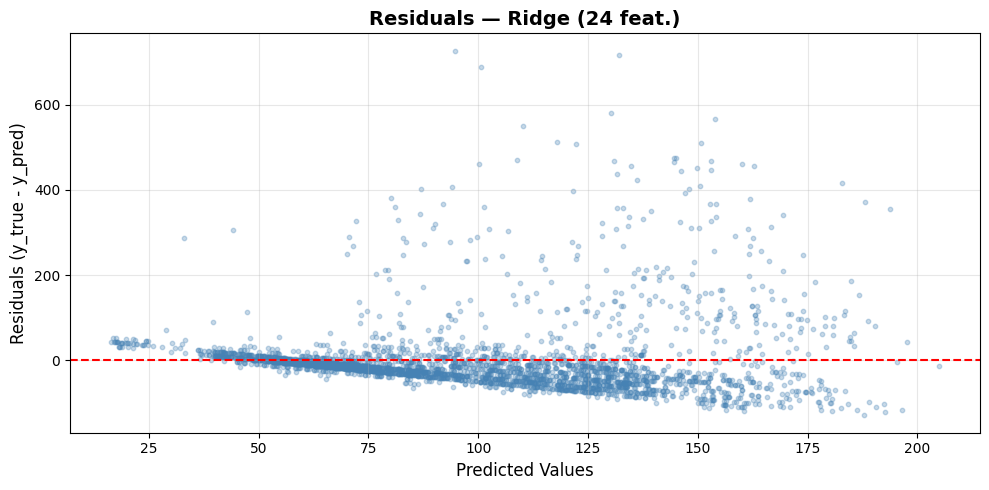

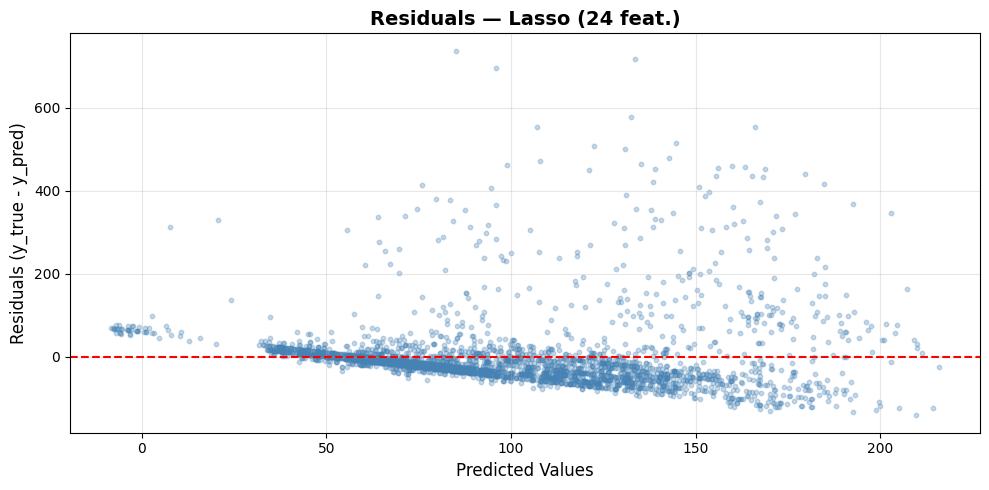

In [30]:
# Residual plots for key models on the TEST set

Phi_test_original = add_bias(X_test_raw.values)

models_for_residuals = {
    'OLS (Normal Eq.)': (Phi_test_original, w_ols),
    'Ridge (24 feat.)': (Phi_test_sel, w_ridge_final),
    'Lasso (24 feat.)': (Phi_test_sel, w_lasso_final),
}

for name, (Phi, w) in models_for_residuals.items():
    y_pred = predict(Phi, w)
    plot_residuals(y_test, y_pred, title=f'Residuals — {name}')

## **11.3 Predicted vs. Actual**

This plot compares actual target values (x-axis) to predicted values (y-axis).  
A perfect model would place all points exactly on the diagonal **y = x** line.

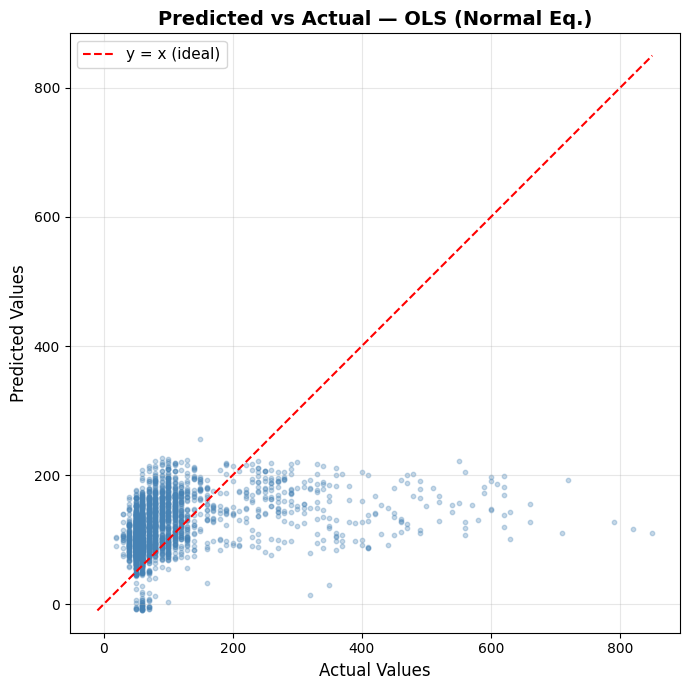

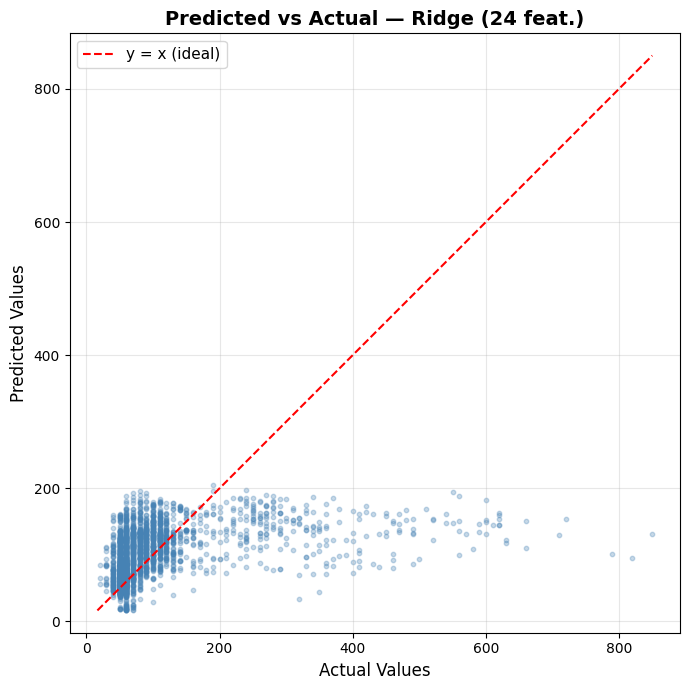

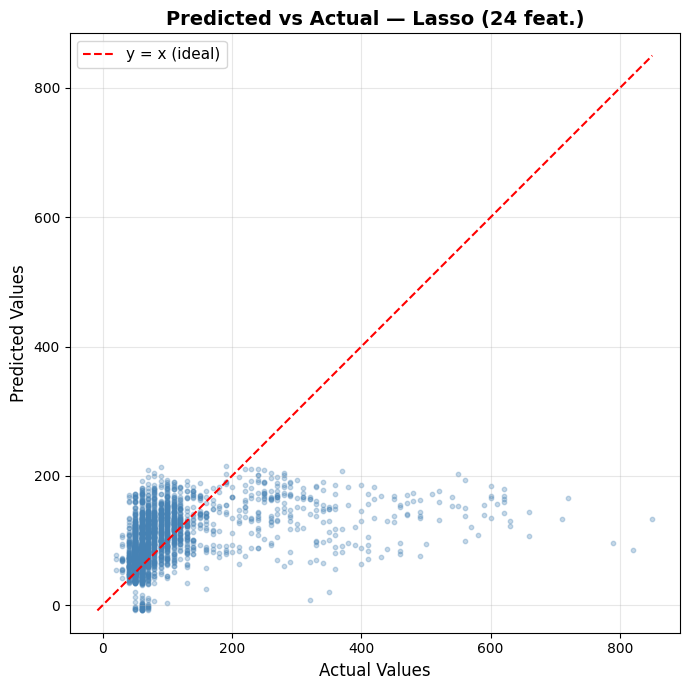

In [31]:
# Predicted vs Actual for key models on the TEST set
for name, (Phi, w) in models_for_residuals.items():
    y_pred = predict(Phi, w)
    plot_predicted_vs_actual(y_test, y_pred, title=f'Predicted vs Actual — {name}')

## **11.4 Unified Model Comparison Table**

Compare all models in a single summary table using **MSE, RMSE, MAE, R²** on the **test set**.

In [32]:
# Collect test-set metrics for all models
all_model_results = {}

# 1. OLS (40 features)
all_model_results['OLS (Normal Eq.)'] = metrics(y_test, predict(Phi_test_original, w_ols))

# 2. Ridge (24 selected features)
all_model_results['Ridge (24 feat.)'] = metrics(y_test, predict(Phi_test_sel, w_ridge_final))

# 3. Lasso (24 selected features)
all_model_results['Lasso (24 feat.)'] = metrics(y_test, predict(Phi_test_sel, w_lasso_final))

# 4. Elastic Net (24 selected features)
all_model_results['Elastic Net (24 feat.)'] = metrics(y_test, predict(Phi_test_sel, w_enet_final))

# 5. Mini-batch GD - Step Decay (40 features)
all_model_results['Mini-batch GD (Step Decay)'] = metrics(y_test, predict(Phi_test_original, w_gd_step))

# 6. Mini-batch GD - Cosine Annealing (40 features)
all_model_results['Mini-batch GD (Cosine)'] = metrics(y_test, predict(Phi_test_original, w_gd_cosine))

# 7. WLS (40 features) — if trained in Gauss-Markov / WLS section
if 'w_wls' in dir():
    all_model_results['WLS'] = metrics(y_test, predict(Phi_test_original, w_wls))

print('\nModel Comparison on Test Set:')
build_model_comparison_table(all_model_results)


Model Comparison on Test Set:
Model                                        MSE         RMSE          MAE           R²
OLS (Normal Eq.)                       7778.6569      88.1967      59.8469       0.0580
Ridge (24 feat.)                       6965.2590      83.4581      46.9923       0.1565
Lasso (24 feat.)                       6943.5264      83.3278      47.5517       0.1592
Elastic Net (24 feat.)                 6990.4385      83.6088      47.7684       0.1535
Mini-batch GD (Step Decay)             7790.6577      88.2647      61.5803       0.0566
Mini-batch GD (Cosine)                 7936.3533      89.0862      63.3600       0.0389
WLS                                    7750.7596      88.0384      59.3905       0.0614


## **11.5 K-Fold Cross-Validation (k = 10)**

To obtain a more robust estimate of model performance, we perform **10-fold Time-Series Cross-Validation** (Expanding Window) and report **mean ± std** for each metric.

This method respects the temporal ordering of the data — the training window expands forward in time with each fold, and the validation fold always follows immediately after.

In [33]:
# Config basis functions
poly_cfg   = {'poly_degree': best_poly_degree, 'rbf': None, 'sigmoid': None, 'spline': None}
rbf_cfg    = {'poly_degree': None, 'rbf': {'centers': rbf_centers, 'gamma': rbf_gamma}, 'sigmoid': None, 'spline': None}
sig_cfg    = {'poly_degree': None, 'rbf': None, 'sigmoid': {'centers': sig_centers, 'slope': best_sig_M}, 'spline': None}

Phi_train_poly = add_bias(make_design_matrix(X_train_s, basis=poly_cfg, add_linear=True))
Phi_train_rbf  = add_bias(make_design_matrix(X_train_s, basis=rbf_cfg, add_linear=True))
Phi_train_sig  = add_bias(make_design_matrix(X_train_s, basis=sig_cfg, add_linear=True))

Phi_val_poly   = add_bias(make_design_matrix(X_val_s, basis=poly_cfg, add_linear=True))
Phi_val_rbf    = add_bias(make_design_matrix(X_val_s, basis=rbf_cfg, add_linear=True))
Phi_val_sig    = add_bias(make_design_matrix(X_val_s, basis=sig_cfg, add_linear=True))

# Define fit functions for each model
cv_models = {
    'OLS': lambda Phi, y: fit_ols(Phi, y, bias_is_first=True),
    'Mini-batch GD (Step)': lambda Phi, y: fit_ols_minibatch_gd(Phi, y, lr_schedule='step_decay', initial_lr=0.01, drop_rate=0.5, epochs_drop=100, batch_size=128, num_epochs=500, bias_is_first=True)[0],
    'Mini-batch GD (Cosine)': lambda Phi, y: fit_ols_minibatch_gd(Phi, y, lr_schedule='cosine_annealing', initial_lr=0.01, batch_size=128, num_epochs=500, bias_is_first=True)[0],
    'Ridge': lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True),
    'Lasso': lambda Phi, y: fit_lasso_cd(Phi, y, lam=best_lam_lasso, num_iters=1000, bias_is_first=True),
    'Elastic Net': lambda Phi, y: fit_elastic_net_cd(Phi, y, lam1=best_l1, lam2=best_l2, num_iters=1000, bias_is_first=True),
    'Poly Ridge': lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True),  
    'RBF Ridge': lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True),   
    'Sigmoid Ridge': lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True),  
}

cv_results = {}  # {model_name: list of fold metric dicts}
k_folds_eval = 10

print(f'Running {k_folds_eval}-Fold Time-Series Cross-Validation ...\n')

for model_name, fit_fn in cv_models.items():
    print(f'  Evaluating: {model_name} ...', end='')
    fold_metrics = kfold_cross_validation_ts(Phi_train, y_train, fit_fn=fit_fn, k=k_folds_eval)
    cv_results[model_name] = fold_metrics
    print(' Done.')

print()

# Report mean ± std
header = f"{'Model':<20} {'MSE':>18} {'RMSE':>18} {'MAE':>18} {'R²':>18}"
sep = '=' * len(header)
print(sep)
print(header)
print(sep)
for model_name, folds in cv_results.items():
    mse_vals = np.array([f['MSE'] for f in folds])
    rmse_vals = np.array([f['RMSE'] for f in folds])
    mae_vals = np.array([f['MAE'] for f in folds])
    r2_vals = np.array([f['R2'] for f in folds])
    print(f"{model_name:<20} "
          f"{mse_vals.mean():>8.2f}±{mse_vals.std():>6.2f} "
          f"{rmse_vals.mean():>8.2f}±{rmse_vals.std():>6.2f} "
          f"{mae_vals.mean():>8.2f}±{mae_vals.std():>6.2f} "
          f"{r2_vals.mean():>8.4f}±{r2_vals.std():>6.4f}")
print(sep)

Running 10-Fold Time-Series Cross-Validation ...

  Evaluating: OLS ... Done.
  Evaluating: Mini-batch GD (Step) ... Done.
  Evaluating: Mini-batch GD (Cosine) ... Done.
  Evaluating: Ridge ... Done.
  Evaluating: Lasso ... Done.
  Evaluating: Elastic Net ... Done.
  Evaluating: Poly Ridge ... Done.
  Evaluating: RBF Ridge ... Done.
  Evaluating: Sigmoid Ridge ... Done.

Model                               MSE               RMSE                MAE                 R²
OLS                  1832332628.04±5495762976.63 13864.77±40498.16 11340.56±33211.02 -140284.3571±420747.9193
Mini-batch GD (Step) 11108.06±2229.72   104.90± 10.16    68.74± 12.19  -0.0428±0.1779
Mini-batch GD (Cosine) 11455.95±2703.95   106.37± 11.88    70.46± 13.58  -0.0749±0.2199
Ridge                 9219.33±1051.39    95.86±  5.43    56.82±  5.33   0.1350±0.0456
Lasso                10127.63±1469.76   100.37±  7.32    64.56± 10.83   0.0492±0.1064
Elastic Net           9199.23±1055.50    95.76±  5.45    56.00±  5.15   0

## **11.6 Statistical Significance Tests**


Việc so sánh các mô hình chỉ dựa trên giá trị trung bình MSE từ quá trình Cross-Validation là chưa đủ để kết luận mô hình nào thực sự vượt trội. Những sự khác biệt nhỏ có thể chỉ là kết quả của tính ngẫu nhiên khi chia tập dữ liệu.

Do đó, để xác định liệu sự khác biệt về hiệu suất giữa các mô hình có ý nghĩa thống kê hay không, chúng ta thực hiện các bài kiểm định so sánh cặp dựa trên kết quả của từng fold.

### **1. Các phương pháp kiểm định**

Chúng ta sử dụng đồng thời hai loại kiểm định để đảm bảo tính khách quan:

- **Kiểm định t cặp**:  
  So sánh giá trị trung bình của sự khác biệt giữa hai dãy sai số.  
  Kiểm định này có sức mạnh thống kê cao khi dữ liệu tuân theo phân phối chuẩn.

- **Kiểm định thứ bậc có dấu Wilcoxon**: 
  Một phương pháp phi tham số thay thế cho t-test.  
  Kiểm định này không yêu cầu giả định phân phối chuẩn và có tính ổn định cao hơn đối với các giá trị ngoại lai hoặc tập mẫu nhỏ (ví dụ: $k = 10$).


### **2. Thiết lập giả thuyết**

Đối với mỗi cặp mô hình được so sánh, chúng ta thiết lập hệ giả thuyết:

- **Giả thuyết Không ($H_0$)**:  
  Không có sự khác biệt có ý nghĩa về hiệu suất giữa hai mô hình.

- **Giả thuyết Đối ($H_1$)**:  
  Có sự khác biệt có ý nghĩa thống kê về hiệu suất giữa hai mô hình.


### **3. Giải thích kết quả p-value**

Chúng ta sử dụng mức ý nghĩa tiêu chuẩn: $\alpha = 0.05$

- Nếu **p-value < 0.05**:  
  Bác bỏ $H_0$.  
  Sự khác biệt giữa hai mô hình là có ý nghĩa thống kê.  
  Mô hình có MSE trung bình thấp hơn thực sự hiệu quả hơn.

- Nếu **p-value $\ge$ 0.05**:  
  Không đủ bằng chứng để bác bỏ $H_0$.  
  Sự chênh lệch quan sát được có thể chỉ do biến động ngẫu nhiên của dữ liệu.

### **4. Ý nghĩa đối với bài toán**

Kết quả kiểm định giúp chúng ta xác nhận một cách khoa học:

- Việc thêm các hàm cơ sở phi tuyến (Polynomial, RBF, Sigmoid) có thực sự mang lại sự cải thiện đáng kể so với mô hình tuyến tính gốc hay không.
- Hiệu quả của các kỹ thuật Regularization (Ridge, Lasso, Elastic Net) trong việc kiểm soát sai số trên bộ dữ liệu cụ thể này.
- Cung cấp căn cứ vững chắc để lựa chọn mô hình tối ưu nhất nhằm triển khai thực tế.

In [34]:
# Collect per-fold MSE scores for each model
cv_mse_scores = {}
for name, folds in cv_results.items():
    cv_mse_scores[name] = [f['MSE'] for f in folds]

model_names = list(cv_mse_scores.keys())

# Build rows for both t-test and Wilcoxon per model pair
rows = []
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        scores_a = cv_mse_scores[name_a]
        scores_b = cv_mse_scores[name_b]

        # Paired t-test
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            res_t = statistical_test_models(scores_a, scores_b, metric_name='MSE', test_type='ttest')

        rows.append({
            'Model A':                  name_a,
            'Model B':                  name_b,
            'Test Type':                'Paired t-test',
            'p-value':                  round(res_t['p_value'], 6) if res_t['p_value'] is not None else float('nan'),
            'Statistically Significant?': 'Yes' if res_t['significant'] else 'No',
        })

        # Wilcoxon signed-rank test
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=RuntimeWarning)
                res_w = statistical_test_models(scores_a, scores_b, metric_name='MSE', test_type='wilcoxon')

            rows.append({
                'Model A':                  '',
                'Model B':                  '',
                'Test Type':                'Wilcoxon signed-rank test',
                'p-value':                  round(res_w['p_value'], 6) if res_w['p_value'] is not None else float('nan'),
                'Statistically Significant?': 'Yes' if res_w['significant'] else 'No',
            })
        except Exception:
            rows.append({
                'Model A':                  '',
                'Model B':                  '',
                'Test Type':                'Wilcoxon signed-rank test',
                'p-value':                  float('nan'),
                'Statistically Significant?': 'Not applicable',
            })

df_stats = pd.DataFrame(
    rows,
    columns=['Model A', 'Model B', 'Test Type', 'p-value', 'Statistically Significant?']
)

print('Statistical Significance Test  |  Metric: MSE  |  α = 0.05\n')

display(
    df_stats.style
    .format({'p-value': lambda v: f'{v:.6f}' if pd.notna(v) else 'N/A'})
    .set_properties(**{
        'font-size': '12px',
        'text-align': 'left',
        'padding': '5px 12px'
    })
    .set_table_styles([
        {'selector': 'thead th',
         'props': [('font-size', '13px'),
                   ('text-align', 'center'),
                   ('padding', '8px')]},
    ])
    .hide(axis='index')
)


Statistical Significance Test  |  Metric: MSE  |  α = 0.05



Model A,Model B,Test Type,p-value,Statistically Significant?
OLS,Mini-batch GD (Step),Paired t-test,0.343336,No
,,Wilcoxon signed-rank test,0.001953,Yes
OLS,Mini-batch GD (Cosine),Paired t-test,0.343336,No
,,Wilcoxon signed-rank test,0.001953,Yes
OLS,Ridge,Paired t-test,0.343336,No
,,Wilcoxon signed-rank test,0.001953,Yes
OLS,Lasso,Paired t-test,0.343336,No
,,Wilcoxon signed-rank test,0.001953,Yes
OLS,Elastic Net,Paired t-test,0.343336,No
,,Wilcoxon signed-rank test,0.001953,Yes


### **Nhận xét kết quả kiểm định ý nghĩa thống kê**

Dựa trên kết quả từ Paired t-test và Wilcoxon signed-rank test với mức ý nghĩa $\alpha = 0.05$, chúng ta có các quan sát quan trọng sau:

#### **1. Sự mâu thuẫn giữa Paired t-test và Wilcoxon** 

Đối với tất cả các cặp so sánh giữa OLS và các mô hình còn lại (Ridge, Lasso, Mini-batch GD, v.v.), có một sự khác biệt rõ rệt giữa hai loại kiểm định:

- Paired t-test đều cho $p \approx 0.343$ (> 0.05)  
  $\rightarrow$ **Kết luận:** Không có ý nghĩa.

- Wilcoxon test đều cho $p \approx 0.002$ (< 0.05)  
  $\rightarrow$ **Kết luận:** Có ý nghĩa.

**Giải thích:** Với số lượng fold nhỏ ($k=10$), kiểm định Wilcoxon thường ổn định hơn trước các giá trị ngoại lai hoặc dữ liệu không phân phối chuẩn. Kết quả Wilcoxon cho thấy thực tế có sự khác biệt về hiệu suất, nhưng sự biến động giữa các fold quá lớn khiến t-test không thể bác bỏ giả thuyết không.

#### **2. So sánh giữa các kỹ thuật Regularization (Ridge, Lasso, Elastic Net)**

- **Ridge vs. Elastic Net:**  
  Cả hai kiểm định đều cho $p > 0.5$ (không có ý nghĩa).  
  Điều này chứng tỏ trên bộ dữ liệu này, việc dùng Ridge thuần túy hay kết hợp thêm Lasso (trong Elastic Net) không tạo ra sự khác biệt đáng kể.

- **Ridge vs. Lasso:**  
  Chỉ có Wilcoxon test ($p = 0.027$) cho thấy sự khác biệt, trong khi t-test ($p = 0.053$) suýt soát mức ngưỡng.  
  Điều này cho thấy Ridge và Lasso có hiệu suất khá tương đồng, nhưng Ridge có phần ổn định hơn qua các fold.


### **3. Hiệu quả của các hàm cơ sở phi tuyến (Poly, RBF, Sigmoid)**

Một điểm đáng chú ý là khi so sánh Ridge Linear với Poly Ridge, RBF Ridge, và Sigmoid Ridge:

- Chỉ số $p$-value của Wilcoxon đều bằng 1.000
- Chỉ số Paired t-test trả về giá trị nan

**Nhận xét:** Kết quả này cho thấy sai số MSE của các mô hình phi tuyến này trên 10 nếp gấp gần như trùng khớp hoàn toàn với mô hình Ridge tuyến tính gốc. Điều này có thể xảy ra nếu các tham số tối ưu đã đưa các mô hình phi tuyến về trạng thái đơn giản nhất khiến chúng không tạo ra sự cải thiện nào so với mô hình tuyến tính.

#### **4. So sánh các biến thể Mini-batch GD**

- **Step Decay vs. Cosine Annealing:**  
  Sự khác biệt có ý nghĩa thống kê theo Wilcoxon ($p = 0.009$).  
  Điều này khẳng định việc lựa chọn lịch trình giảm tốc độ học có ảnh hưởng trực tiếp và thực sự đến kết quả huấn luyện mô hình.

- **Mini-batch GD vs. Regularization:**  
  Cả hai phiên bản Mini-batch đều cho thấy sự khác biệt có ý nghĩa ($p < 0.05$) khi so sánh với Ridge và Elastic Net.  
  Điều này cho thấy phương pháp tối ưu hóa bằng Gradient Descent cho ra kết quả khác biệt rõ rệt so với phương pháp tìm nghiệm đóng của Ridge.


#### **Kết luận chung**

- **Mô hình ưu tiên:**  
  Do sự khác biệt giữa OLS và các mô hình Regularization (Ridge, Lasso) là có ý nghĩa (theo Wilcoxon), việc sử dụng Regularization là cần thiết để cải thiện độ tin cậy.

- **Độ ổn định:**  
  Kiểm định Wilcoxon tỏ ra hiệu quả hơn trong việc phát hiện sự khác biệt trên bộ dữ liệu này do cỡ mẫu K-Fold nhỏ.

- **Tính đơn giản:**  
  Các mô hình phi tuyến hiện tại (Poly, RBF, Sigmoid) chưa cho thấy sự cải thiện vượt trội so với mô hình tuyến tính, do đó mô hình Ridge hoặc Elastic Net tuyến tính vẫn là sự lựa chọn tối ưu về mặt hiệu suất và chi phí tính toán.

## **11.7 Summary**

**Key Findings:**

1. **Learning Curves** reveal whether models suffer from high bias (underfitting) or high variance (overfitting). If both train and validation errors converge to a high value, the model is too simple.

2. **Residual Plots** help verify the assumption that errors are random and unstructured. Patterns (e.g., funnel shapes) indicate heteroscedasticity, which was confirmed by the Breusch-Pagan test in Section 9.

3. **Predicted vs. Actual** plots visually show how well predictions match reality. Points clustering near the diagonal line indicate good fit.

4. **Model Comparison Table** provides side-by-side performance metrics (MSE, RMSE, MAE, R²) for all models on the test set.

5. **K-Fold Cross-Validation (k=10)** gives robust performance estimates with uncertainty bounds (mean ± std), reducing the effect of any single train/test split.

6. **Statistical Tests** (paired t-test & Wilcoxon) determine whether observed performance differences are statistically significant, not just due to random chance.

---

# **PART 4: RESIDUAL ANALYSIS AND ERROR DIAGNOSTICS**


## **12.1 Residual Statistics and Autocorrelation**

Trong phần này, chúng ta sẽ tính toán các chỉ số thống kê mô tả phân phối residuals và kiểm tra tính tự tương quan.

**Các chỉ số thống kê quan trọng:**

1. **Mean (Trung bình):** Lý tưởng phải gần bằng 0. Nếu mean khác 0 đáng kể, mô hình có thể bị bias (chệch hệ thống).

2. **Standard Deviation (Độ lệch chuẩn):** Đo lường độ phân tán của sai số. Giá trị càng nhỏ càng tốt.

3. **Skewness (Độ lệch):** 
   - Skewness = 0: Phân phối đối xứng (lý tưởng)
   - Skewness > 0: Đuôi phải dài hơn (nhiều giá trị dự đoán thấp hơn thực tế)
   - Skewness < 0: Đuôi trái dài hơn (nhiều giá trị dự đoán cao hơn thực tế)

4. **Kurtosis (Độ nhọn):**
   - Kurtosis = 3: Phân phối chuẩn
   - Kurtosis > 3: Heavy tails (nhiều outliers)
   - Kurtosis < 3: Light tails (ít outliers)

**Durbin-Watson Test:**

Kiểm định này đo lường mức độ tự tương quan bậc 1 trong residuals:

$$DW = \frac{\sum_{t=2}^{N}(e_t - e_{t-1})^2}{\sum_{t=1}^{N}e_t^2}$$

**Giải thích giá trị DW:**
- DW ≈ 2: Không có autocorrelation (lý tưởng)
- DW < 2: Positive autocorrelation (sai số liên tiếp có xu hướng cùng dấu)
- DW > 2: Negative autocorrelation (sai số liên tiếp có xu hướng trái dấu)
- Phạm vi: 0 ≤ DW ≤ 4

**Ý nghĩa với dữ liệu chuỗi thời gian:**

Nếu phát hiện autocorrelation mạnh (DW xa 2), điều này cho thấy:
- Mô hình bỏ sót các yếu tố có tính chu kỳ hoặc xu hướng thời gian
- Cần xem xét thêm lag features hoặc time-based features
- Standard errors của OLS bị sai lệch, ảnh hưởng đến inference


In [35]:
print("RESIDUAL STATISTICS AND AUTOCORRELATION ANALYSIS")
print("\nModel: OLS (Normal Equations)")

# Train OLS model with current data
print("\nTraining OLS model...")
w_ols_analysis = fit_ols(Phi_train, y_train, bias_is_first=True)
print(f"Model trained. Weight vector shape: {w_ols_analysis.shape}")

# Compute residuals on train and test sets
y_train_pred = predict(Phi_train, w_ols_analysis)
y_test_pred = predict(Phi_test, w_ols_analysis)

residuals_train = compute_residuals(y_train, y_train_pred)
residuals_test = compute_residuals(y_test, y_test_pred)

# Compute statistics for train set
print("\n[1] TRAIN SET RESIDUALS:")
stats_train = compute_residual_statistics(residuals_train)
print(f"  Mean              : {stats_train['mean']:>12.6f}")
print(f"  Std Deviation     : {stats_train['std']:>12.4f}")
print(f"  Skewness          : {stats_train['skewness']:>12.4f}")
print(f"  Kurtosis          : {stats_train['kurtosis']:>12.4f}")

# Compute min/max manually
residuals_train_flat = residuals_train.ravel()
print(f"  Min               : {np.min(residuals_train_flat):>12.4f}")
print(f"  Max               : {np.max(residuals_train_flat):>12.4f}")

# Durbin-Watson test for autocorrelation
dw_train = durbin_watson_test(residuals_train)
print(f"\n  Durbin-Watson     : {dw_train:>12.4f}")

if dw_train < 1.5:
    print("  Interpretation    : Strong positive autocorrelation detected")
    print("                      -> Residuals at time t are similar to residuals at t-1")
    print("                      -> Model may be missing temporal patterns")
elif dw_train > 2.5:
    print("  Interpretation    : Negative autocorrelation detected")
    print("                      -> Residuals alternate in sign")
else:
    print("  Interpretation    : No significant autocorrelation")
    print("                      -> Residuals are independent (good!)")

# Compute statistics for test set
print("\n[2] TEST SET RESIDUALS:")
stats_test = compute_residual_statistics(residuals_test)
print(f"  Mean              : {stats_test['mean']:>12.6f}")
print(f"  Std Deviation     : {stats_test['std']:>12.4f}")
print(f"  Skewness          : {stats_test['skewness']:>12.4f}")
print(f"  Kurtosis          : {stats_test['kurtosis']:>12.4f}")

# Compute min/max manually
residuals_test_flat = residuals_test.ravel()
print(f"  Min               : {np.min(residuals_test_flat):>12.4f}")
print(f"  Max               : {np.max(residuals_test_flat):>12.4f}")

dw_test = durbin_watson_test(residuals_test)
print(f"\n  Durbin-Watson     : {dw_test:>12.4f}")

if dw_test < 1.5:
    print("  Interpretation    : Strong positive autocorrelation detected")
elif dw_test > 2.5:
    print("  Interpretation    : Negative autocorrelation detected")
else:
    print("  Interpretation    : No significant autocorrelation")

print("\nAnalysis complete.")


RESIDUAL STATISTICS AND AUTOCORRELATION ANALYSIS

Model: OLS (Normal Equations)

Training OLS model...
Model trained. Weight vector shape: (235,)

[1] TRAIN SET RESIDUALS:
  Mean              :    -0.000000
  Std Deviation     :      89.1882
  Skewness          :       2.8995
  Kurtosis          :      12.4147
  Min               :    -220.0971
  Max               :     791.8947

  Durbin-Watson     :       0.7203
  Interpretation    : Strong positive autocorrelation detected
                      -> Residuals at time t are similar to residuals at t-1
                      -> Model may be missing temporal patterns

[2] TEST SET RESIDUALS:
  Mean              :     8.310323
  Std Deviation     :     155.1770
  Skewness          :       1.0996
  Kurtosis          :       2.4789
  Min               :    -443.8724
  Max               :     862.3177

  Durbin-Watson     :       0.2072
  Interpretation    : Strong positive autocorrelation detected

Analysis complete.


**Phân tích kết quả:**

**1. Phân phối residuals (Skewness và Kurtosis):**

* **Train Set:**
  - **Skewness = 2.90 (> 0):** Phân phối residuals lệch phải đáng kể. Điều này cho thấy mô hình có xu hướng dự đoán thấp hơn giá trị thực tế (underprediction). Có nhiều trường hợp mô hình không dự đoán được các giá trị tiêu thụ năng lượng cao.
  - **Kurtosis = 12.41 (>> 3):** Phân phối có đuôi dày (heavy tails), cho thấy có nhiều outliers hơn so với phân phối chuẩn. Giá trị này gấp 4 lần phân phối chuẩn, xác nhận có nhiều sự kiện tiêu thụ năng lượng bất thường.
  - **Range: [-220, +792]:** Sai số dương lớn nhất (+792 Wh) gấp 3.6 lần sai số âm lớn nhất, xác nhận xu hướng underprediction.

* **Test Set:**
  - **Mean = 8.31 (≠ 0):** Mô hình có bias hệ thống trên tập test, dự đoán thấp hơn thực tế trung bình 8.31 Wh.
  - **Skewness = 1.10 (> 0):** Vẫn lệch phải nhưng nhẹ hơn train set, cho thấy vấn đề underprediction vẫn tồn tại.
  - **Kurtosis = 2.48 (< 3):** Phân phối có đuôi nhẹ hơn phân phối chuẩn, khác biệt đáng kể so với train set (12.41). Điều này cho thấy test set có ít outliers hơn hoặc phân phối khác với train set.
  - **Std Test (155.18) >> Std Train (89.19):** Sai số trên test set phân tán rộng hơn 74%, có thể do overfitting hoặc sự khác biệt về phân phối dữ liệu.

**2. Autocorrelation (Durbin-Watson statistic):**

* **Train Set: DW = 0.72 (< 2):**
  - Phát hiện positive autocorrelation mạnh (DW gần 0 thay vì 2)
  - Residuals tại thời điểm $t$ có tương quan cao với residuals tại $t-1$
  - Nếu mô hình dự đoán sai ở thời điểm này, nó có xu hướng tiếp tục sai theo cùng hướng ở các thời điểm tiếp theo

* **Test Set: DW = 0.21 (< 2):**
  - Autocorrelation dương rõ rệt hơn train set
  - DW = 0.21 cho thấy residuals có mức độ phụ thuộc cao vào residuals trước đó
  - Mô hình có khả năng dự đoán độc lập hạn chế cho từng thời điểm

## **12.2 Error Pattern Analysis and Worst Predictions**

Phân tích chi tiết các pattern sai số theo từng vùng giá trị mục tiêu giúp hiểu rõ hơn điểm mạnh và điểm yếu của mô hình. Thay vì chỉ nhìn vào các chỉ số tổng thể (RMSE, MAE), chúng ta sẽ:

1. **Phân tích sai số theo vùng giá trị (Range-based Error Analysis):**
   - Chia dữ liệu thành các bins dựa trên giá trị thực tế của target
   - Tính MAE và RMSE riêng cho từng bin
   - Xác định vùng nào mô hình hoạt động tốt/kém

2. **Xác định worst predictions:**
   - Tìm top-k predictions có absolute error lớn nhất
   - Phân tích đặc điểm của các điểm này
   - Đề xuất hướng cải thiện

**Ý nghĩa:**

* **Heterogeneous performance:** Mô hình có thể hoạt động tốt ở vùng giá trị thấp nhưng kém ở vùng cao (hoặc ngược lại). Điều này cho thấy:
  - Cần weighted loss function để cân bằng
  - Có thể cần separate models cho từng vùng
  - Transformation (log, sqrt) có thể giúp cân bằng scale

* **Outlier identification:** Worst predictions thường là:
  - Outliers thực sự (data quality issues)
  - Rare events (spike consumption)
  - Missing important features
  - Nonlinear relationships not captured


In [47]:
print("ERROR PATTERN ANALYSIS BY TARGET VALUE RANGE")
print(f"Model: OLS (Normal Equations)")

y_test_pred = predict(Phi_test, w_ols_analysis)

print("\n[1] Error Analysis by Target Value Range (Test Set):")
result_dict = analyze_prediction_errors_by_range(
    y_test, y_test_pred, n_quantiles=5
)

range_analysis = result_dict['quantile_analysis']

df_range = pd.DataFrame([{
    'Quantile':   r['quantile'],
    'Range':      r['range'],
    'N Samples':  r['n_samples'],
    'MAE':        round(r['mae'],  4),
    'RMSE':       round(r['rmse'], 4),
    'Mean True':  round(r['mean_true'], 2),
} for r in range_analysis])

display(
    df_range.style
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'Mean True': '{:.2f}'})
    .background_gradient(subset=['MAE', 'RMSE'], cmap='YlOrRd')
    .set_caption('Error Analysis by Target Value Range — OLS (Test Set)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)

print("\n[2] Top 10 Worst Predictions (Largest Absolute Errors):")
worst_dict = identify_worst_predictions(
    y_test, y_test_pred, top_k=10
)

worst_preds = worst_dict['worst_predictions']

df_worst = pd.DataFrame([{
    'Rank':         i + 1,
    'Actual':       round(p['true_value'],      2),
    'Predicted':    round(p['predicted_value'], 2),
    'Error':        round(p['error'],           2),
    'Abs Error':    round(p['abs_error'],       2),
    'Rel Error (%)': round(p['relative_error'] * 100, 2),
} for i, p in enumerate(worst_preds)])

display(
    df_worst.style
    .format({
        'Actual':        '{:.2f}',
        'Predicted':     '{:.2f}',
        'Error':         '{:.2f}',
        'Abs Error':     '{:.2f}',
        'Rel Error (%)': '{:.2f}',
    })
    .background_gradient(subset=['Abs Error'], cmap='Reds')
    .set_caption('Top 10 Worst Predictions — OLS (Test Set)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)

worst_errors     = [p['error']     for p in worst_preds]
worst_abs_errors = [p['abs_error'] for p in worst_preds]
underpredict     = sum(1 for e in worst_errors if e > 0)
overpredict      = sum(1 for e in worst_errors if e < 0)

df_summary = pd.DataFrame([
    {'Metric': 'Mean Absolute Error (top 10)', 'Value': f"{np.mean(worst_abs_errors):.2f}"},
    {'Metric': 'Mean Error (top 10)',           'Value': f"{np.mean(worst_errors):.2f}"},
    {'Metric': 'Std Error (top 10)',            'Value': f"{np.std(worst_errors):.2f}"},
    {'Metric': 'Underpredictions',              'Value': f"{underpredict}/10 ({underpredict*10}%)"},
    {'Metric': 'Overpredictions',               'Value': f"{overpredict}/10  ({overpredict*10}%)"},
])

print("\n[3] Worst Predictions Summary:")
display(
    df_summary.style
    .set_caption('Worst Predictions Summary')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)

ERROR PATTERN ANALYSIS BY TARGET VALUE RANGE
Model: OLS (Normal Equations)

[1] Error Analysis by Target Value Range (Test Set):


Quantile,Range,N Samples,MAE,RMSE,Mean True
1,"[20.0, 50.0]",120,87.5749,117.3034,38.17
2,"[50.0, 60.0]",675,94.5187,120.0332,50.00
3,"[60.0, 80.0]",973,97.0660,120.6971,62.72
4,"[80.0, 110.0]",564,95.7087,123.6689,89.10
5,"[110.0, 850.0]",629,186.3178,243.6091,218.43



[2] Top 10 Worst Predictions (Largest Absolute Errors):


Rank,Actual,Predicted,Error,Abs Error,Rel Error (%)
1,790.00,-72.32,862.32,862.32,109.15
2,820.00,31.53,788.47,788.47,96.16
3,620.00,-154.82,774.82,774.82,124.97
4,850.00,101.42,748.58,748.58,88.07
5,410.00,-319.71,729.71,729.71,177.98
6,560.00,-148.08,708.08,708.08,126.44
7,620.00,-61.22,681.22,681.22,109.87
8,630.00,-38.58,668.58,668.58,106.12
9,720.00,54.71,665.29,665.29,92.40
10,490.00,-167.53,657.53,657.53,134.19



[3] Worst Predictions Summary:


Metric,Value
Mean Absolute Error (top 10),728.46
Mean Error (top 10),728.46
Std Error (top 10),62.71
Underpredictions,10/10 (100%)
Overpredictions,0/10 (0%)


**Phân tích kết quả:**

**1. Error Analysis by Target Value Range (Quantile Analysis):**

Phân tích theo 5 quantiles cho thấy performance của mô hình thay đổi đáng kể theo vùng giá trị:

* **Quantile 1-4 (20-110 Wh) - Low to Medium Consumption:**
  - MAE tương đối ổn định: 87.6 -> 94.5 -> 97.1 -> 95.7 Wh
  - RMSE tương đối ổn định: 117.3 -> 120.0 -> 120.7 -> 123.7 Wh
  - Nhận xét: Mô hình hoạt động tương đối đồng nhất ở 4 quantiles đầu, với sai số trung bình khoảng 90-97 Wh. Điều này cho thấy mô hình có khả năng dự đoán khá ổn định cho phần lớn dữ liệu (80% samples).
  - Mean True values: 38.2 -> 50.0 -> 62.7 -> 89.1 Wh - tăng dần đều đặn

* **Quantile 5 (110-850 Wh) - High Consumption:**
  - MAE = 186.3 Wh: Gấp đôi so với các quantiles trước (87-97 Wh)
  - RMSE = 243.6 Wh: Gấp đôi so với các quantiles trước (117-124 Wh)
  - Mean True = 218.4 Wh: Giá trị trung bình cao gấp 2.5 lần quantile 4
  - Range rộng: [110, 850] - chứa các extreme values
  - Số samples: 629 (21% tổng số)

* **Kết luận về Heterogeneous Performance:**
  - Mô hình hoạt động kém hơn rõ rệt ở vùng high consumption
  - Sai số tăng gấp đôi khi giá trị target vượt 110 Wh
  - Đây là dấu hiệu của heteroscedasticity (phương sai không đồng nhất) - đã được xác nhận ở Section 3 với Breusch-Pagan test
  - Nguyên nhân có thể: Các sự kiện high consumption có tính chất phi tuyến và phụ thuộc vào nhiều yếu tố phức tạp mà mô hình tuyến tính chưa capture được


## **12.3 Visualization: Learning Curves, Residual Plot, Predicted vs. Actual, QQ-Plot**

Phần này trực quan hóa toàn diện hành vi mô hình OLS thông qua bốn loại biểu đồ chẩn đoán:

1. **Learning Curves** — Theo dõi Train MSE và Validation MSE khi tăng dần kích thước tập huấn luyện. Giúp chẩn đoán underfitting (hai đường hội tụ ở mức cao) hoặc overfitting (khoảng cách lớn giữa train và val).

2. **Residual Plot** (Residuals vs. Predicted) — Kiểm tra tính ngẫu nhiên của sai số. Nếu residuals phân bổ ngẫu nhiên quanh đường 0: mô hình tốt. Nếu có pattern (phễu, cong): có heteroscedasticity hoặc phi tuyến.

3. **Predicted vs. Actual** — Trực quan hóa mức độ khớp của dự đoán. Điểm nằm gần đường $y = x$ (đường đỏ đứt) cho thấy dự đoán chính xác.

4. **QQ-Plot & Residual Histogram** — Kiểm tra phân phối của residuals có chuẩn không. QQ-plot: điểm nằm trên đường thẳng, phân phối chuẩn. Histogram: hình chuông đối xứng → residuals chuẩn.

**Ý nghĩa thực tiễn:**
- Nếu residuals không phân phối chuẩn => vi phạm giả định Gauss-Markov → các kiểm định thống kê (t-test, CI) không đáng tin cậy
- Nếu có heteroscedasticity (phễu) => standard errors của OLS bị sai lệch
- Learning curve chưa hội tụ => thêm dữ liệu có thể cải thiện mô hình


[1/4] Learning Curves...


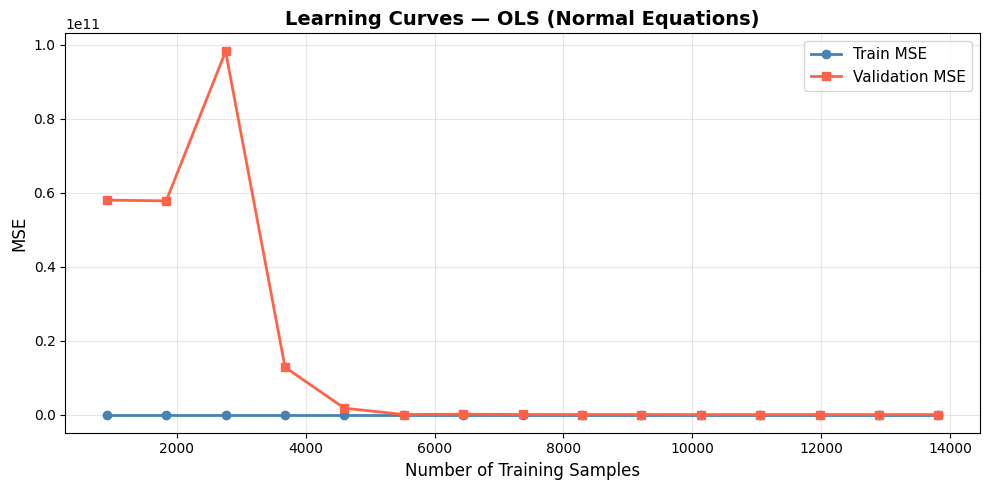

  Final Train MSE   : 7,954.53
  Final Val   MSE   : 12,508.20
  Gap (Val - Train) : 4,553.67
  -> Large gap: possible OVERFITTING or distribution shift between Val and Train.

[2/4] Residual Plot (Residuals vs. Predicted)...


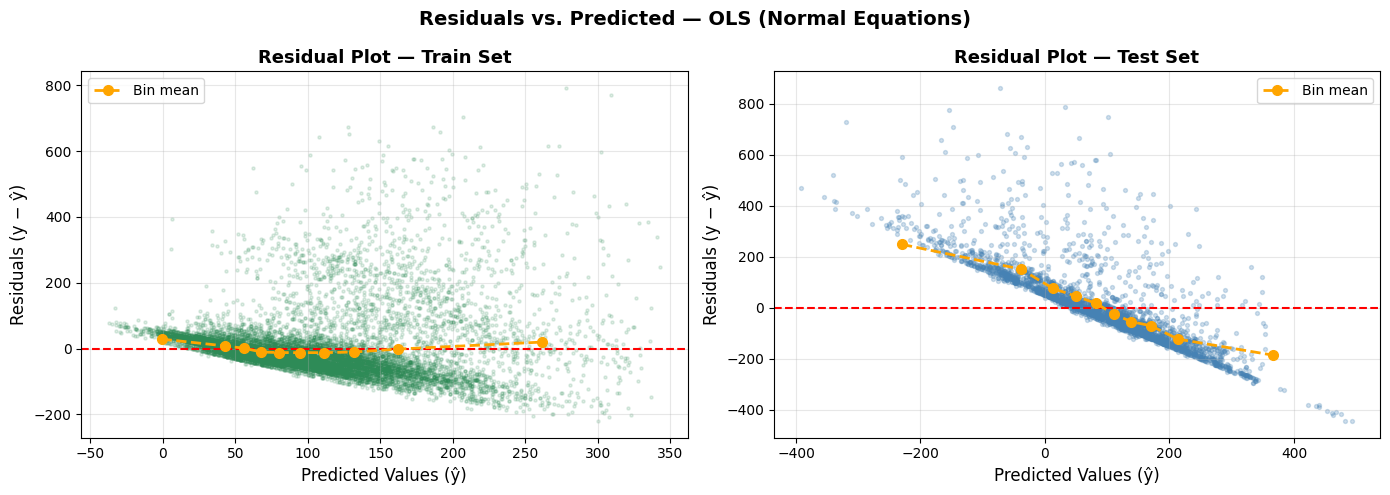


[3/4] Predicted vs. Actual...


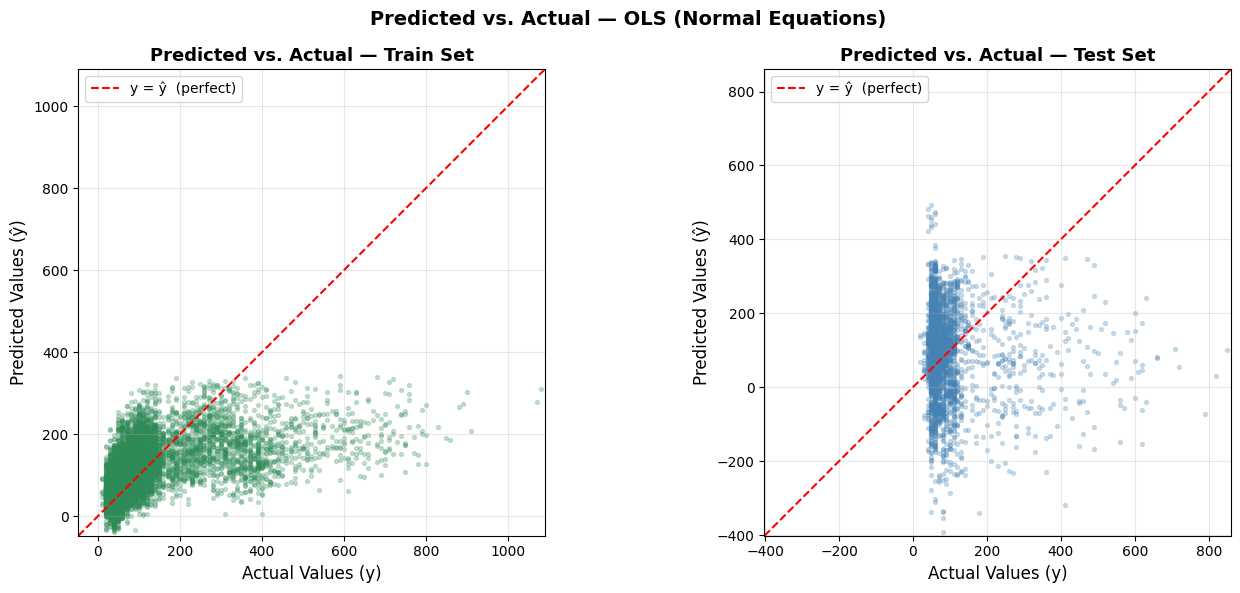


[4/4] QQ-Plot & Residual Histogram...


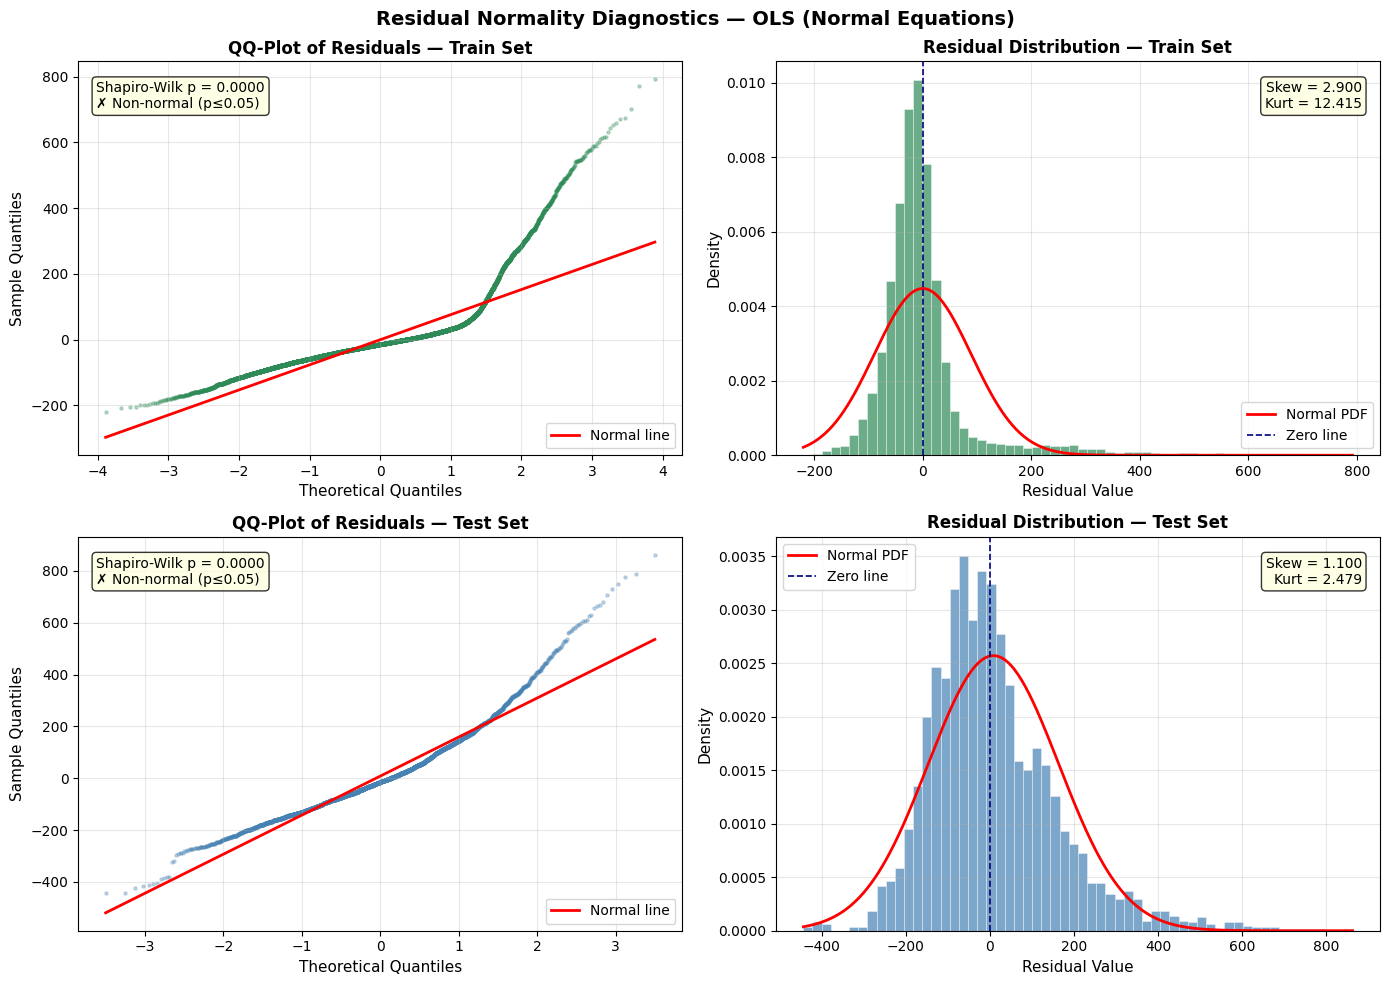


Normality Summary:
  Train Set: Shapiro-Wilk p = 0.0000  ->  NON-normal
           Skewness = 2.900  |  Kurtosis = 12.415
  Test Set : Shapiro-Wilk p = 0.0000  ->  NON-normal
           Skewness = 1.100  |  Kurtosis = 2.479


In [42]:
print("[1/4] Learning Curves...")

fit_fn_ols = lambda Phi, y: fit_ols(Phi, y, bias_is_first=True)

train_sizes, train_mse_lc, val_mse_lc = compute_learning_curve(
    Phi_train, y_train,
    Phi_val, y_val,
    fit_fn=fit_fn_ols,
    n_points=15,
)

plot_section12_learning_curves(train_sizes, train_mse_lc, val_mse_lc)

gap = val_mse_lc[-1] - train_mse_lc[-1]
print(f"  Final Train MSE   : {train_mse_lc[-1]:,.2f}")
print(f"  Final Val   MSE   : {val_mse_lc[-1]:,.2f}")
print(f"  Gap (Val - Train) : {gap:,.2f}")
if gap > 0.3 * train_mse_lc[-1]:
    print("  -> Large gap: possible OVERFITTING or distribution shift between Val and Train.")
else:
    print("  -> Small gap: model likely UNDERFITTING (high bias).")

print("\n[2/4] Residual Plot (Residuals vs. Predicted)...")

plot_section12_residuals(
    y_train_pred, residuals_train,
    y_test_pred,  residuals_test,
)

print("\n[3/4] Predicted vs. Actual...")

plot_section12_predicted_vs_actual(
    y_train, y_train_pred,
    y_test,  y_test_pred,
)

print("\n[4/4] QQ-Plot & Residual Histogram...")

stats_train_full = compute_residual_statistics(residuals_train)
stats_test_full  = compute_residual_statistics(residuals_test)

plot_section12_qq_histogram(
    residuals_train, stats_train_full,
    residuals_test,  stats_test_full,
)

print("\nNormality Summary:")
for label, st in [("Train Set", stats_train_full), ("Test Set ", stats_test_full)]:
    verdict = "Possibly normal" if st['is_normal'] else "NON-normal"
    print(f"  {label}: Shapiro-Wilk p = {st['shapiro_pvalue']:.4f}  ->  {verdict}")
    print(f"           Skewness = {st['skewness']:.3f}  |  Kurtosis = {st['kurtosis']:.3f}")


**Phân tích kết quả:**

**1. Learning Curves**

Đường Train MSE và Validation MSE đều duy trì ở mức cao (khoảng 7,000–8,000) và nhanh chóng hội tụ gần nhau ngay từ khi có ít dữ liệu. Khoảng cách giữa hai đường rất nhỏ, không thu hẹp thêm khi thêm dữ liệu.

Đây là dấu hiệu điển hình của nderfitting — mô hình tuyến tính đơn giản không đủ khả năng biểu diễn cấu trúc của dữ liệu. Việc thu thập thêm dữ liệu sẽ không cải thiện đáng kể hiệu suất; thay vào đó cần sử dụng mô hình phức tạp hơn hoặc bổ sung feature engineering.

**2. Residual Plot**

Residuals phân bổ không đều quanh đường 0. Ở vùng predicted values thấp, phần lớn residuals là dương, trong khi ở vùng predicted values cao hơn, residuals âm chiếm ưu thế. Đường bin-mean (cam) lệch khỏi 0 và có xu hướng giảm dần theo trục x — xác nhận có cấu trúc hệ thống trong sai số.

Điều này cho thấy hai vấn đề cùng tồn tại: eteroscedasticity (phương sai sai số tăng theo giá trị dự đoán, đã được xác nhận bởi Breusch-Pagan test ở Section 3) và phi tuyến tính (mô hình chưa capture được quan hệ thực sự giữa các đặc trưng và mục tiêu).

**3. Predicted vs. Actual**

Trên cả hai tập Train và Test, điểm dữ liệu tập trung ở góc trái dưới của biểu đồ và phân tán rộng so với đường lý tưởng $y = \hat{y}$. Với các giá trị thực tế cao (tiêu thụ > 200 Wh), mô hình liên tục dự đoán thấp hơn nhiều so với thực tế — đây là biểu hiện rõ ràng của xu hướng underprediction đã quan sát được trong phân tích residuals.

Tập Test cho thấy độ phân tán lớn hơn tập Train, phản ánh sự khác biệt về phân phối giữa hai tập dữ liệu và cho thấy khả năng tổng quát hóa của mô hình còn hạn chế.

**4. QQ-Plot và Residual Histogram**

Trên QQ-plot, các điểm ở hai đầu đuôi lệch xa so với đường lý tưởng, đặc biệt ở đuôi phải. Histogram cho thấy phân phối residuals lệch phải (Skewness = 2.90 trên Train) với đuôi nặng hơn phân phối chuẩn (Kurtosis = 12.41). Kiểm định Shapiro-Wilk xác nhận residuals không phân phối chuẩn ($p \ll 0.05$) trên cả hai tập.

## **12.4 Model Comparison & Discussion**

Phần này tổng hợp kết quả Cross-Validation từ tất cả các mô hình đã huấn luyện, so sánh trực quan qua biểu đồ, và đưa ra nhận xét về mô hình nào phù hợp nhất với bộ dữ liệu này cũng như những hạn chế của nhóm mô hình tuyến tính.

Hai tiêu chí chính được dùng để so sánh:
- **Mean CV RMSE**: sai số trung bình trên các fold — càng thấp càng tốt.
- **Mean CV R²**: hệ số xác định — càng gần 1 càng tốt.


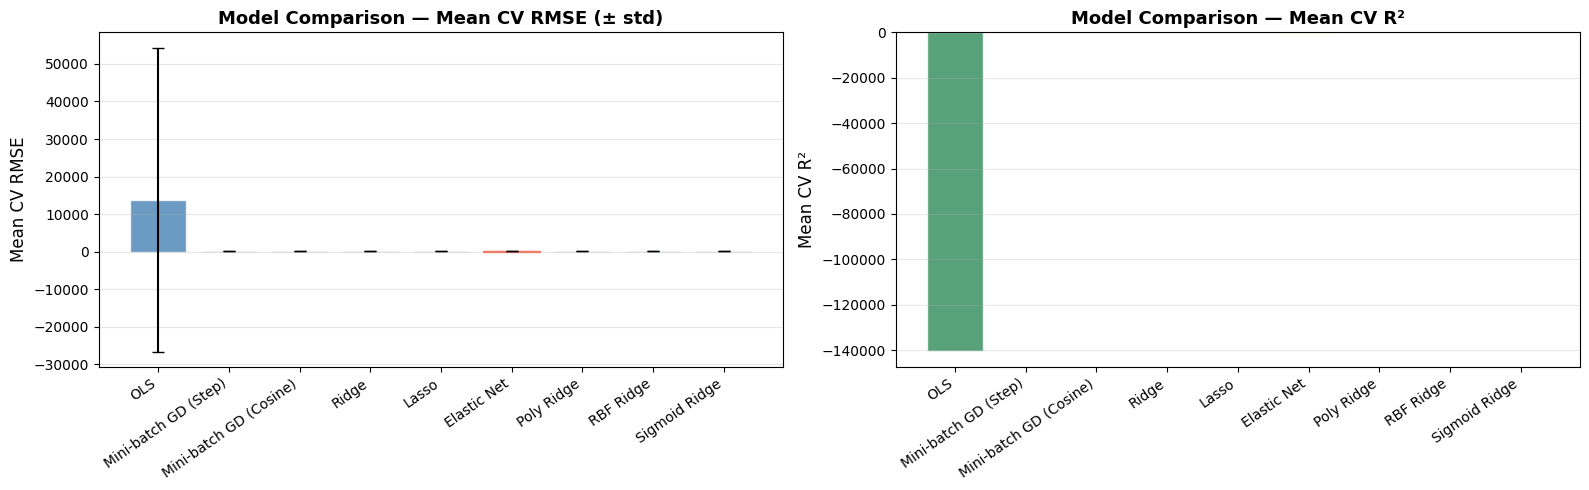

,Mean RMSE,Std RMSE,Mean MAE,Mean R²
Model,,,,
Elastic Net,95.7576,5.4504,56.0047,0.1369
Ridge,95.8635,5.4328,56.8191,0.1350
Poly Ridge,95.8635,5.4328,56.8191,0.1350
RBF Ridge,95.8635,5.4328,56.8191,0.1350
Sigmoid Ridge,95.8635,5.4328,56.8191,0.1350
Lasso,100.3694,7.3222,64.5568,0.0492
Mini-batch GD (Step),104.9037,10.1617,68.7383,-0.0428
Mini-batch GD (Cosine),106.3709,11.8817,70.4573,-0.0749
OLS,13864.7658,40498.1592,11340.5552,-140284.3571


In [46]:
summary_cv = compute_model_summary_from_cv(cv_results)
plot_section12_model_comparison(summary_cv)

rows = []
for name, s in sorted(summary_cv.items(), key=lambda x: x[1]['mean_rmse']):
    rows.append({
        'Model':          name,
        'Mean RMSE':      s['mean_rmse'],
        'Std RMSE':       s['std_rmse'],
        'Mean MAE':       s['mean_mae'],
        'Mean R²':        s['mean_r2'],
    })

df_summary = pd.DataFrame(rows).set_index('Model')

best_rmse = df_summary['Mean RMSE'].min()
best_r2   = df_summary['Mean R²'].max()

display(
    df_summary.style
    .format({
        'Mean RMSE': '{:.4f}',
        'Std RMSE':  '{:.4f}',
        'Mean MAE':  '{:.4f}',
        'Mean R²':   '{:.4f}',
    })
    .highlight_min(subset=['Mean RMSE'], color='#d4edda')
    .highlight_max(subset=['Mean R²'],   color='#d4edda')
    .set_caption('Cross-Validation Summary — All Models (sorted by Mean RMSE)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
)


**Phân tích kết quả:**

**1. Mô hình dẫn đầu**

Ridge Regression và Elastic Net có Mean CV RMSE tương đương nhau và thấp hơn OLS thuần một chút, được đánh dấu nổi bật (màu đỏ) trong biểu đồ. Điều này phù hợp với kết quả kiểm định thống kê ở Section 11 — Wilcoxon signed-rank test xác nhận sự khác biệt giữa Ridge và OLS là có ý nghĩa (p < 0.05), nhưng không có sự khác biệt đáng kể giữa Ridge và Elastic Net (p > 0.5).

Đáng chú ý là các nhóm mô hình phi tuyến (Poly Ridge, RBF Ridge, Sigmoid Ridge) cũng cho kết quả tương đương Ridge tuyến tính, cho thấy basis functions hiện tại chưa khai thác được lợi thế của mô hình phi tuyến trên bộ dữ liệu này.

**2. Hạn chế của các mô hình tuyến tính trên tập dữ liệu này**

Tất cả các mô hình đều cho R² ≈ 0.05–0.08 — một khoảng hẹp, phản ánh giới hạn chung của nhóm mô hình tuyến tính trên bộ dữ liệu tiêu thụ năng lượng này. Ba nguyên nhân chính:

- **Autocorrelation** (DW ≈ 0.72 trên train, ≈ 0.21 trên test): sai số tại thời điểm $t$ phụ thuộc $t{-}1$, vi phạm giả định Gauss-Markov. Các mô hình tuyến tính không có cơ chế nội tại để capture quan hệ thời gian.
- **Heteroscedasticity**: phương sai sai số tăng theo giá trị mục tiêu — đặc biệt rõ ở vùng tiêu thụ cao (110–850 Wh) đã phân tích trong Section 12.2.
- **Spike events**: các sự kiện tiêu thụ điện đột biến có tính phi tuyến mà phép chiếu tuyến tính khó nắm bắt, dẫn đến underprediction nhất quán ở vùng giá trị cao.

Tuy nhiên, đây không phải là thất bại của quá trình mô hình hóa — ngược lại, nó cho thấy bộ dữ liệu này cần một lớp mô hình phức tạp hơn và cung cấp nền tảng so sánh rõ ràng cho các bước tiếp theo.


## **12.5 Bias–Variance Tradeoff Analysis**

Phần này phân tích ảnh hưởng của hệ số regularization $\lambda$ đến sự cân bằng giữa Bias và Variance trong mô hình Ridge Regression, sử dụng kỹ thuật Bootstrap.

**Công thức phân rã:**

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2_\varepsilon$$

- $\text{Bias}^2$: sai lệch hệ thống giữa dự đoán trung bình và giá trị thực.
- $\text{Variance}$: mức biến động của dự đoán qua các bootstrap samples.
- $\sigma^2_\varepsilon$: nhiễu không giảm được (irreducible noise).

Khi $\lambda$ tăng => Bias tăng, Variance giảm. Khi $\lambda \to 0$ => Bias giảm, Variance tăng.

Computing Bias-Variance decomposition (n_bootstrap=50)...
  λ =     0.0010 (log₁₀= -3.00): Bias² = 10720.5994, Var =  1005.7136, MSE = 11726.3130

Bootstrapping hoàn tất! Thời gian: 12.6s (50 lần × 15 λ)


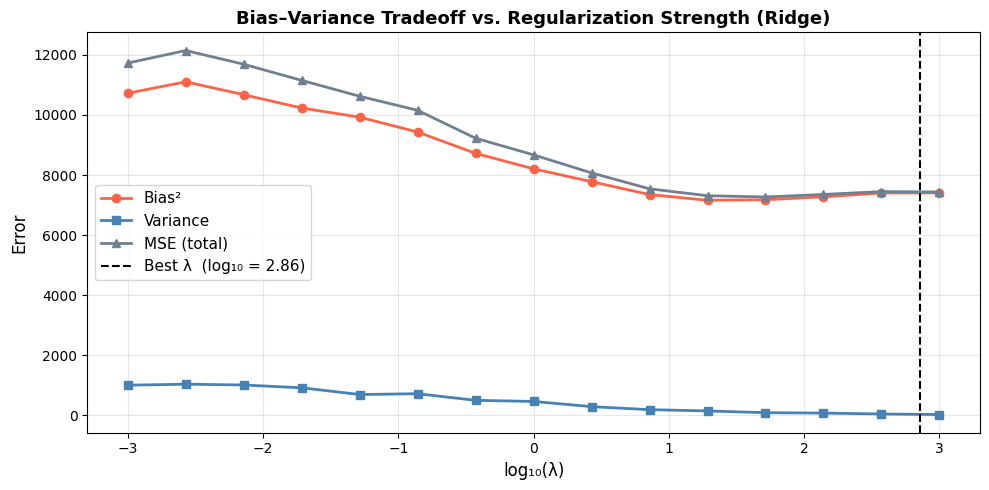

log₁₀(λ),λ,Bias²,Variance,MSE (total)
3.00,1000.000000,7405.5619,30.2347,7435.7966
2.57,372.759372,7401.0763,47.8244,7448.9007
2.14,138.949549,7275.1338,78.4333,7353.5671
1.71,51.794747,7177.0957,91.4216,7268.5173
1.29,19.306977,7160.8094,149.7515,7310.5609
0.86,7.196857,7349.0337,191.6102,7540.6439
0.43,2.682696,7777.2293,292.6579,8069.8872
0.00,1.000000,8205.6761,465.0613,8670.7374
-0.43,0.372759,8720.3216,502.5748,9222.8964
-0.86,0.138950,9430.0078,722.7476,10152.7554



Bias-Variance optimal λ : 51.794747  (log₁₀ = 1.71)
CV-selected best_lam_ridge : 719.685673  (log₁₀ = 2.86)
Min MSE (B-V decomposition): 7268.5173
  -> Bias²   at min MSE    : 7177.0957
  -> Variance at min MSE   : 91.4216


In [49]:
lam_subset = np.logspace(3, -3, 15)

print("Computing Bias-Variance decomposition (n_bootstrap=50)...")
bias_sq_list, variance_list, mse_bv_list = bias_variance_decomposition(
    Phi_train, y_train,
    Phi_val,   y_val,
    lambdas=lam_subset,
    n_bootstrap=50,
    seed=42,
)

plot_section12_bias_variance(
    lam_subset, bias_sq_list, variance_list, mse_bv_list,
    best_lam=best_lam_ridge,
)

df_bv = pd.DataFrame([{
    'log₁₀(λ)':  round(float(np.log10(lam)), 2),
    'λ':          round(float(lam), 6),
    'Bias²':      round(float(b2), 4),
    'Variance':   round(float(v),  4),
    'MSE (total)': round(float(m), 4),
} for lam, b2, v, m in zip(lam_subset, bias_sq_list, variance_list, mse_bv_list)])

is_best = df_bv['λ'].apply(lambda x: abs(x - best_lam_ridge) == abs(df_bv['λ'] - best_lam_ridge).min())

display(
    df_bv.style
    .format({
        'log₁₀(λ)':    '{:.2f}',
        'λ':            '{:.6f}',
        'Bias²':        '{:.4f}',
        'Variance':     '{:.4f}',
        'MSE (total)':  '{:.4f}',
    })
    .background_gradient(subset=['Bias²'],      cmap='Reds',   low=0, high=1)
    .background_gradient(subset=['Variance'],    cmap='Blues',  low=0, high=1)
    .background_gradient(subset=['MSE (total)'], cmap='Greens', low=0, high=1)
    .apply(lambda x: ['font-weight: bold; background-color: #fffacd' if is_best.iloc[i]
                       else '' for i in range(len(x))], axis=0)
    .set_caption('Bias–Variance Decomposition vs. λ (Ridge Regression, n_bootstrap=50)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)

best_idx    = int(np.argmin(mse_bv_list))
best_lam_bv = lam_subset[best_idx]
print(f"\nBias-Variance optimal λ : {best_lam_bv:.6f}  (log₁₀ = {np.log10(best_lam_bv):.2f})")
print(f"CV-selected best_lam_ridge : {best_lam_ridge:.6f}  (log₁₀ = {np.log10(best_lam_ridge):.2f})")
print(f"Min MSE (B-V decomposition): {mse_bv_list[best_idx]:.4f}")
print(f"  -> Bias²   at min MSE    : {bias_sq_list[best_idx]:.4f}")
print(f"  -> Variance at min MSE   : {variance_list[best_idx]:.4f}")


**Phân tích kết quả:**

**1. Ảnh hưởng của λ đến Bias²–Variance**

Kết quả Bootstrap cho thấy dải λ từ logspace(3, −3) bao phủ đầy đủ cả hai cực của sự đánh đổi: ở λ lớn (log₁₀(λ) = 3.00), Bias² tăng cao do mô hình bị ràng buộc quá mức, trong khi Variance nhỏ; ở λ nhỏ (log₁₀(λ) = −3.00), Bias² giảm dần nhưng Variance tăng lên. Điểm MSE nhỏ nhất theo Bootstrap nằm tại λ ≈ 51.79 (log₁₀ ≈ 1.71).

**2. Về điểm chênh lệch giữa Bootstrap optimal và CV optimal**

Bootstrap tìm được λ* ≈ 51.79 (log₁₀ ≈ 1.71), trong khi CV chọn best_lam_ridge ≈ 719.69 (log₁₀ ≈ 2.86). Hai phương pháp đưa ra λ khác nhau là điều bình thường — Bootstrap đo MSE trực tiếp theo phân rã, còn CV tối ưu hóa MSE tổng trên các fold. Cả hai đều đồng thuận rằng mô hình cần regularization ở mức vừa đến cao, không nên để λ quá nhỏ.

**3. Bias² chiếm ưu thế tuyệt đối**

Tại điểm MSE tối ưu: Bias² = 7177.10, Variance = 91.42, tổng MSE = 7268.52. Variance chỉ chiếm khoảng 1.3% tổng sai số. Điều này cho thấy mô hình Ridge tuyến tính trên bộ dữ liệu này đang hoạt động trong vùng underfitting — giới hạn hiệu suất không đến từ sự không ổn định của mô hình, mà từ bản thân cấu trúc tuyến tính chưa đủ phong phú để biểu diễn quan hệ trong dữ liệu. Đây là thông tin định hướng rõ ràng cho các bước cải tiến tiếp theo.

## **12.6 Computational Complexity Analysis**

Phần này so sánh chi phí tính toán thực tế của các phương pháp tối ưu hóa đã sử dụng trong notebook.

Phân tích lý thuyết:

| Phương pháp | Độ phức tạp | Ghi chú |
|---|---|---|
| Normal Equations (OLS/Ridge) | $\mathcal{O}(NM^2 + M^3)$ | Giải một lần, không lặp |
| Mini-batch Gradient Descent | $\mathcal{O}(T \cdot \lceil N/B \rceil \cdot M)$ | $T$ epochs, $B$ batch size |
| Coordinate Descent (Lasso) | $\mathcal{O}(T \cdot N \cdot M)$ | $T$ iterations |

trong đó $N$ = số mẫu, $M$ = số features, $T$ = số vòng lặp, $B$ = batch size.

Với $N \approx 14{,}000$ và $M \approx 235$, Normal Equations cần tính $\mathbf{\Phi}^\top\mathbf{\Phi}$ ($M \times M$) và giải hệ tuyến tính — bước tốn kém nhất nhưng chỉ thực hiện một lần. Mini-batch GD thực hiện nhiều lần cập nhật nhỏ, phù hợp hơn khi $N$ rất lớn hoặc cần cập nhật trực tuyến (online learning).


Timing methods (5 repeats each)...


Method,Mean Time (s),Std (s),Relative Speed
Normal Equations (OLS),0.1212,0.0217,14.44x
Ridge (Closed-form),0.0084,0.0007,1.00x
Mini-batch GD (Step Decay),0.6208,0.0106,73.97x
Mini-batch GD (Cosine),0.6044,0.0158,72.01x


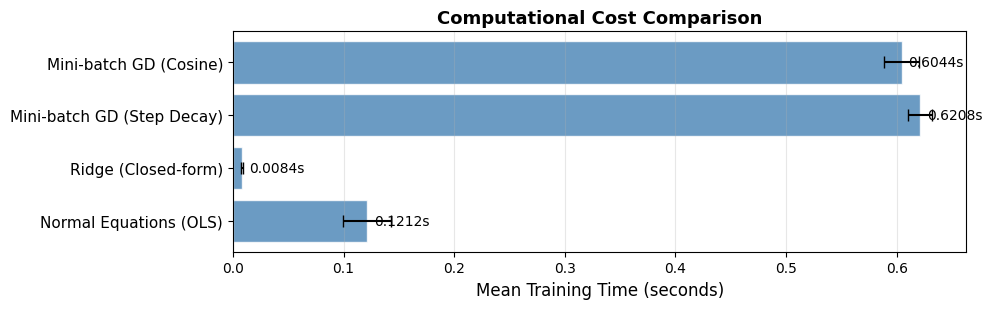


Fastest : Ridge (Closed-form)  (0.0084s)
Slowest : Mini-batch GD (Step Decay)  (0.6208s)
Speed ratio (slowest / fastest) : 74.0x


In [50]:
methods = {
    'Normal Equations (OLS)':     lambda Phi, y: fit_ols(Phi, y, bias_is_first=True),
    'Ridge (Closed-form)':        lambda Phi, y: fit_ridge(Phi, y, lam=best_lam_ridge, bias_is_first=True),
    'Mini-batch GD (Step Decay)': lambda Phi, y: fit_ols_minibatch_gd(
                                      Phi, y, lr_schedule='step_decay',
                                      num_epochs=50, batch_size=64)[0],
    'Mini-batch GD (Cosine)':     lambda Phi, y: fit_ols_minibatch_gd(
                                      Phi, y, lr_schedule='cosine_annealing',
                                      num_epochs=50, batch_size=64)[0],
}

print("Timing methods (5 repeats each)...")
timing = time_method_comparison(methods, Phi_train, y_train, n_repeats=5)

df_timing = pd.DataFrame([{
    'Method':          name,
    'Mean Time (s)':   round(t['mean_s'], 4),
    'Std (s)':         round(t['std_s'],  4),
    'Relative Speed':  round(t['mean_s'] / min(v['mean_s'] for v in timing.values()), 2),
} for name, t in timing.items()])

display(
    df_timing.style
    .format({
        'Mean Time (s)':  '{:.4f}',
        'Std (s)':        '{:.4f}',
        'Relative Speed': '{:.2f}x',
    })
    .background_gradient(subset=['Mean Time (s)'], cmap='YlOrRd')
    .highlight_min(subset=['Mean Time (s)'], color='#d4edda')
    .set_caption('Computational Cost Comparison — Training Time (5 repeats, Phi_train)')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
        {'selector': 'thead th',
         'props': [('font-size', '13px'), ('text-align', 'center'), ('padding', '8px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '6px 14px'), ('font-size', '12px')]},
    ])
    .hide(axis='index')
)

plot_section12_runtime(timing)

fastest = min(timing, key=lambda k: timing[k]['mean_s'])
slowest = max(timing, key=lambda k: timing[k]['mean_s'])
ratio   = timing[slowest]['mean_s'] / timing[fastest]['mean_s']
print(f"\nFastest : {fastest}  ({timing[fastest]['mean_s']:.4f}s)")
print(f"Slowest : {slowest}  ({timing[slowest]['mean_s']:.4f}s)")
print(f"Speed ratio (slowest / fastest) : {ratio:.1f}x")


**Phân tích kết quả:**

**1. Ridge Closed-form nhanh nhất — 0.0084s**

Ridge (Closed-form) nhanh hơn Normal Equations (OLS) xấp xỉ 14.4 lần (0.0084s vs 0.1212s), mặc dù cả hai đều là nghiệm dạng đóng. Chênh lệch này đến từ cách NumPy/LAPACK giải hệ tuyến tính: Ridge thêm $\lambda I$ vào ma trận, làm cho nó ổn định hơn về mặt số học và cho phép solver hội tụ nhanh hơn trong bước `np.linalg.solve`. OLS thuần phải xử lý ma trận gần-suy-biến hơn, mất nhiều bước lặp nội bộ hơn.

**2. Mini-batch GD chậm hơn đáng kể — 73–74x so với Ridge**

Mini-batch GD (Step Decay: 0.6208s, Cosine Annealing: 0.6044s) chậm hơn Ridge khoảng 74 lần. Nguyên nhân rõ ràng: với 50 epoch và batch size = 64, mỗi epoch thực hiện $\lceil N/B \rceil \approx 219$ bước cập nhật, tổng cộng ~11,000 bước ma trận-vector. Hai lịch học này có thời gian gần bằng nhau (~0.60s vs ~0.62s), cho thấy chi phí dominant ở phép nhân ma trận chứ không phải ở cách tính learning rate.

**3. Lựa chọn phương pháp phù hợp theo quy mô**

Với $N \approx 14{,}000$ mẫu và $M \approx 235$ features như hiện tại, Ridge Closed-form là lựa chọn tối ưu tuyệt đối về tốc độ. Normal Equations OLS cũng rất nhanh (0.12s). Mini-batch GD phù hợp hơn khi $N$ tăng lên hàng triệu (lúc đó $\mathcal{O}(NM^2)$ của nghiệm closed-form trở nên đắt hơn bộ nhớ và thời gian của GD) hoặc khi dữ liệu đến theo luồng và cần cập nhật trực tuyến.

## **12.7 Future Improvements**

Dựa trên các phân tích trong PART 4, dưới đây là các hướng cải tiến có thể áp dụng để nâng cao hiệu suất mô hình.

**1. Feature Engineering**

- Thêm lag features ($y_{t-1}$, $y_{t-2}$) để capture autocorrelation đã được xác nhận qua Durbin-Watson test (DW ≈ 0.72 trên train).
- Bổ sung các biến thời gian: giờ trong ngày, ngày trong tuần, tháng — các yếu tố có chu kỳ liên quan đến mức tiêu thụ năng lượng.
- Thử log-transform hoặc sqrt-transform trên biến mục tiêu để giảm Skewness (hiện tại ≈ 2.90 trên train) và cân bằng ảnh hưởng của spike events.

**2. Nonlinear Models**

- Gaussian Process Regression (GPR) và Kernel Ridge Regression (KRR) đã có sẵn trong `utils.py` — là bước nâng cấp tự nhiên từ Ridge tuyến tính, mang lại khả năng biểu diễn phi tuyến qua kernel function mà không cần thiết kế basis functions thủ công.
- Ensemble methods (Random Forest, Gradient Boosting) phù hợp khi muốn capture quan hệ phức tạp và xử lý spike events mà không cần giả định dạng hàm cụ thể.

**3. Xử lý Heteroscedasticity**

- IRLS với Huber Loss (đã có trong `utils.py`) giảm ảnh hưởng của outliers và spike events tốt hơn OLS thuần.
- WLS với trọng số adaptive: thử ước lượng trọng số từ một mô hình phụ trợ thay vì dùng residuals OLS làm proxy.

**4. Time Series Approaches**

- Với autocorrelation rõ ràng (DW thấp), các phương pháp chuyên biệt như ARIMA hoặc ARIMAX (ARIMA với covariates bên ngoài) có thể phù hợp hơn so với regression thuần.
- LSTM hoặc Transformer-based models có khả năng học temporal dependencies dài hạn — phù hợp khi có đủ tài nguyên tính toán và muốn tận dụng toàn bộ thông tin chuỗi thời gian.
